# InstantMesh Fine-Tuning BaliMask3D — I4 Topology-Aware Max Refinement

Notebook ini adalah strategi **I4** yang lebih serius untuk meningkatkan kemiripan hasil ke GT BaliMask3D.

Perbedaan utama dari I2/I3:
- tidak sekadar membuka layer lebih banyak,
- start dari checkpoint terbaik I2/I3 jika tersedia,
- tetap memakai dynamic 6-view subset agar kompatibel dengan arsitektur InstantMesh,
- supervision mask + depth + normal dibuat lebih dominan,
- anchor loss dinaikkan agar prior pretrained/I3 tidak rusak,
- checkpoint selection lebih berat ke TMD/topology,
- menambahkan edge/depth-normal consistency loss untuk menahan mesh noisy.


## Strategi I4 — topology-aware max refinement

**Tujuan I4:** memperbaiki kelemahan utama I2/I3, yaitu TMD/topology yang masih buruk, tanpa mengorbankan CD/UHD terlalu banyak.

Strategi:
1. Ambil checkpoint terbaik dari I3 atau I2 sebagai `ckpt_in`.
2. Trainable tetap level I3: decoder + last transformer block.
3. LR lebih kecil dari I3 agar refinement tidak merusak pretrained prior.
4. Loss dibuat topology-safe:
   - mask/silhouette lebih kuat,
   - depth/normal lebih kuat,
   - depth edge dan normal edge ditambahkan,
   - anchor lebih kuat,
   - symmetry lebih kuat.
5. TMD dihitung setiap epoch dan dipakai dominan untuk checkpoint selection.

Catatan: I4 tetap bukan jaminan mutlak lebih bagus dari pretrained di semua metrik. Target realistisnya adalah meningkatkan CD/UHD sambil menekan TMD dibanding I2/I3. Jika TMD tetap tinggi, stage berikutnya harus post-optimization.


In [1]:
# Cell 1: Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Cell 2: Clone repo + install dependency
%cd /content/drive/MyDrive/Tugas_Akhir

!rm -rf InstantMesh-clean
!git clone https://github.com/TencentARC/InstantMesh.git InstantMesh-clean

%cd /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean

!pip -q uninstall -y huggingface_hub accelerate diffusers transformers pytorch-lightning lightning-fabric peft rembg cupy cupy-cuda12x cupy-cuda11x jax jaxlib flax chex orbax-checkpoint || true
!pip -q install -U pip setuptools wheel packaging jedi
!pip -q install numpy==1.26.4 scipy pandas openpyxl omegaconf einops
!pip -q install pillow opencv-python imageio imageio-ffmpeg matplotlib plotly trimesh xatlas plyfile PyMCubes
!pip -q install torchmetrics webdataset tensorboard safetensors sentencepiece
!pip -q install huggingface_hub==0.25.2 accelerate==0.27.2 diffusers==0.26.3 transformers==4.38.2
!pip -q install ripser persim ninja
!pip -q install git+https://github.com/NVlabs/nvdiffrast.git --no-build-isolation

print("Install selesai. Kalau ini run pertama, restart runtime lalu lanjut dari Cell 3.")

/content/drive/.shortcut-targets-by-id/1OKbOAl3EJdjiW_r44luBzfMH-JjTT3JD/Tugas_Akhir
Cloning into 'InstantMesh-clean'...
remote: Enumerating objects: 334, done.
remote: Counting objects: 100% (176/176), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 334 (delta 130), reused 102 (delta 102), pack-reused 158 (from 1)
Receiving objects: 100% (334/334), 33.55 MiB | 25.73 MiB/s, done.
Resolving deltas: 100% (138/138), done.
/content/drive/.shortcut-targets-by-id/1OKbOAl3EJdjiW_r44luBzfMH-JjTT3JD/Tugas_Akhir/InstantMesh-clean
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
nx-cugraph-cu12 26.2.0 requires cupy-cuda12x>=13.6.0, which is not installed.
torchtune 0.6.1 requires huggingface_hub[hf_transfer], which is not installed.
cudf-cu12 26.2.1 requires cupy-cuda12x>=13.6.0, which is not installed.
sentence-transformers 5.4.1 requires huggingface-

In [3]:
# Cell 3: Verify GPU + nvdiffrast
import sys
import importlib.util
import torch

print("Python:", sys.version)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")
print("nvdiffrast:", importlib.util.find_spec("nvdiffrast"))

import nvdiffrast.torch as dr
print("nvdiffrast OK")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
CUDA: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
nvdiffrast: ModuleSpec(name='nvdiffrast', loader=<_frozen_importlib_external.SourceFileLoader object at 0x78307ca50d70>, origin='/usr/local/lib/python3.12/dist-packages/nvdiffrast/__init__.py', submodule_search_locations=['/usr/local/lib/python3.12/dist-packages/nvdiffrast'])
nvdiffrast OK


In [4]:
# Cell 4: Paths — Colab/Drive standardized
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/Tugas_Akhir')
REPO_ROOT = PROJECT_ROOT / 'InstantMesh-clean'
DATASET_ROOT = PROJECT_ROOT / 'Dataset' / 'BaliMask3D'

# Metadata final yang sudah berisi RGB, mask, depth, normal, camera, dan GT mesh.
# Jika file ini belum ada, cell berikutnya otomatis membuat versi Colab dari metadata lokal.
METADATA_CSV = DATASET_ROOT / 'metadata' / 'balimask3d_bali36_rgb_mask_depth_normal_exact_rgb_setup_split_COLAB.csv'
LOCAL_METADATA_CSV = DATASET_ROOT / 'metadata' / 'balimask3d_bali36_rgb_mask_depth_normal_exact_rgb_setup_split.csv'

OUT_ROOT = PROJECT_ROOT / 'Outputs' / 'finetune' / 'instantmesh_finetune_balimask_I4_topology_aware_max_v1'
CKPT_ROOT = OUT_ROOT / 'checkpoints'
LOG_ROOT = OUT_ROOT / 'logs'
MESHVAL_ROOT = OUT_ROOT / 'meshval'
SHOWCASE_ROOT = OUT_ROOT / 'showcase'

for p in [OUT_ROOT, CKPT_ROOT, LOG_ROOT, MESHVAL_ROOT, SHOWCASE_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('REPO_ROOT:', REPO_ROOT)
print('DATASET_ROOT:', DATASET_ROOT)
print('METADATA_CSV:', METADATA_CSV)
print('OUT_ROOT:', OUT_ROOT)


PROJECT_ROOT: /content/drive/MyDrive/Tugas_Akhir
REPO_ROOT: /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean
DATASET_ROOT: /content/drive/MyDrive/Tugas_Akhir/Dataset/BaliMask3D
METADATA_CSV: /content/drive/MyDrive/Tugas_Akhir/Dataset/BaliMask3D/metadata/balimask3d_bali36_rgb_mask_depth_normal_exact_rgb_setup_split_COLAB.csv
OUT_ROOT: /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I4_topology_aware_max_v1


In [5]:
# Cell 5: Build/check Colab metadata
import pandas as pd
from pathlib import Path

LOCAL_PREFIX = '/home/birhasani/Tugas_Akhir'
COLAB_PREFIX = '/content/drive/MyDrive/Tugas_Akhir'

if not METADATA_CSV.exists():
    if not LOCAL_METADATA_CSV.exists():
        raise FileNotFoundError(f'Metadata tidak ditemukan: {LOCAL_METADATA_CSV}')
    df_meta_tmp = pd.read_csv(LOCAL_METADATA_CSV)
    path_cols = ['rgb_path', 'mask_path', 'depth_path', 'depth_exr_path', 'normal_path', 'depth_stats_path', 'camera_json', 'gt_mesh_path']
    for col in path_cols:
        if col in df_meta_tmp.columns:
            df_meta_tmp[col] = df_meta_tmp[col].astype(str).str.replace(LOCAL_PREFIX, COLAB_PREFIX, regex=False)
    METADATA_CSV.parent.mkdir(parents=True, exist_ok=True)
    df_meta_tmp.to_csv(METADATA_CSV, index=False)
    print('Created Colab metadata:', METADATA_CSV)
else:
    print('Colab metadata exists:', METADATA_CSV)

# Quick check
_df_check = pd.read_csv(METADATA_CSV)
print('metadata rows:', len(_df_check))
print('columns:', _df_check.columns.tolist())
for col in ['rgb_path', 'mask_path', 'depth_path', 'normal_path', 'gt_mesh_path', 'camera_json']:
    if col in _df_check.columns:
        print(col, _df_check[col].head(1).iloc[0], '| exists:', Path(str(_df_check[col].head(1).iloc[0])).exists())


Colab metadata exists: /content/drive/MyDrive/Tugas_Akhir/Dataset/BaliMask3D/metadata/balimask3d_bali36_rgb_mask_depth_normal_exact_rgb_setup_split_COLAB.csv
metadata rows: 972
columns: ['mask_id', 'view_id', 'view_name', 'radius_used', 'rgb_path', 'mask_path', 'depth_path', 'depth_exr_path', 'normal_path', 'depth_stats_path', 'camera_json', 'camera_dn_json', 'gt_mesh_path', 'ok_rgb', 'ok_mask', 'ok_depth', 'ok_depth_exr', 'ok_normal', 'ok_stats', 'ok_camera', 'ok_mesh', 'ok_all', 'split', 'view_index', 'mesh_src_path', 'camera_json_path', 'depth_vis_path', 'normal_png_path']
rgb_path /content/drive/MyDrive/Tugas_Akhir/Dataset/BaliMask3D/Renders_bali36_v1/1/rgb/000.png | exists: True
mask_path /content/drive/MyDrive/Tugas_Akhir/Dataset/BaliMask3D/Renders_bali36_v1/1/mask/000.png | exists: True
depth_path /content/drive/MyDrive/Tugas_Akhir/Dataset/BaliMask3D/Renders_bali36_v1/1/depth/000.png | exists: True
normal_path /content/drive/MyDrive/Tugas_Akhir/Dataset/BaliMask3D/Renders_bali36_

In [6]:
# Cell 6: Imports
import os
import re
import sys
import json
import time
import random
import shutil
import subprocess
import inspect
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib as mpl
mpl.rcParams["text.usetex"] = False
import matplotlib.pyplot as plt

from omegaconf import OmegaConf
from tqdm.auto import tqdm
from huggingface_hub import hf_hub_download

import trimesh
from scipy.spatial import cKDTree
from ripser import ripser
from persim import wasserstein

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.utils.train_util import instantiate_from_config
from src.utils.camera_util import get_zero123plus_input_cameras, get_circular_camera_poses

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE:', DEVICE)

DEVICE: cuda


## Training stages

I1/I2/I3 dibuat sebagai notebook terpisah agar eksperimen tidak tercampur. Semua eksperimen start dari pretrained bersih kecuali kamu sengaja mengisi `ckpt_in` manual.

In [7]:
# Cell 7: Training configuration — I4_topology_aware_max
IM_CONFIG = REPO_ROOT / 'configs' / 'instant-mesh-large.yaml'

TRAIN_SPLIT = 'train'
VAL_SPLIT = 'val'
TEST_SPLIT = 'test'

# IMPORTANT: InstantMesh encoder expects 6-view camera embeddings.
# Do NOT feed 36 views at once. We exploit all 36 views via dynamic 6-view subsets.
SELECT_VIEW_INDICES = [0, 6, 12, 18, 24, 30]

TRAIN_VIEW_SETS = [
    [0, 6, 12, 18, 24, 30],
    [1, 7, 13, 19, 25, 31],
    [2, 8, 14, 20, 26, 32],
    [3, 9, 15, 21, 27, 33],
    [4, 10, 16, 22, 28, 34],
    [5, 11, 17, 23, 29, 35],
]

VAL_VIEW_SET = [0, 6, 12, 18, 24, 30]
TEST_VIEW_SET = [0, 6, 12, 18, 24, 30]

TRAIN_IMAGE_SIZE = 384
RENDER_SIZE = 384
BATCH_SIZE = 1
NUM_WORKERS = 0

# I4 trainable level: same family as I3, decoder + last transformer block.
DECODER_ONLY_REFERENCE_PARAMS = 204_316
I2_TARGET_MIN_TRAINABLE = 8_000_000
I2_TARGET_MAX_TRAINABLE = 20_000_000
I2_LAST_N_BLOCKS = 1

# I4 runs as one topology-aware refinement stage.
I4_EPOCHS = 18

# Lower LR than I3 to refine without destroying geometry prior.
LR_DECODER = 2e-6
LR_BODY = 5e-8
WEIGHT_DECAY = 1.0e-4
GRAD_CLIP_NORM = 0.30

# I4 topology-safe loss weights.
# RGB is reduced; mask/depth/normal/anchor are strengthened.
RGB_FG_LOSS_WEIGHT = 0.55
RGB_BG_LOSS_WEIGHT = 0.005
MASK_LOSS_WEIGHT = 1.75
MASK_EDGE_LOSS_WEIGHT = 0.60
DEPTH_LOSS_WEIGHT = 1.60
DEPTH_EDGE_LOSS_WEIGHT = 0.45
DEPTH_SMOOTH_LOSS_WEIGHT = 0.015
NORMAL_LOSS_WEIGHT = 1.60
NORMAL_EDGE_LOSS_WEIGHT = 0.35
SYMMETRY_LOSS_WEIGHT = 0.080
ANCHOR_LOSS_WEIGHT = 0.020

# Mesh validation: TMD every epoch. I4 checkpoint is TMD-heavy.
MESHVAL_EVERY = 1
MESHVAL_MAX_OBJECTS = 3
MESHVAL_N_CD = 10000
MESHVAL_N_TMD = 1024
MESHVAL_TMD_EVERY = 1
TMD_MAXDIM = 1
TMD_THRESH = 1.5
EARLY_STOP_PATIENCE = 6

# Reference pretrained metrics from your standardized baseline.
PRETRAINED_REF = {
    'cd': 0.541045,
    'uhd': 0.802961,
    'tmd': 6.298061,
}

# Previous checkpoint candidates. Notebook will use the first existing one.
PREV_I3_ROOT = PROJECT_ROOT / 'Outputs' / 'finetune' / 'instantmesh_finetune_balimask_I3_trainable_plus_supervision_v1' / 'checkpoints'
PREV_I2_ROOT = PROJECT_ROOT / 'Outputs' / 'finetune' / 'instantmesh_finetune_balimask_I2_supervision_same_trainable_v1' / 'checkpoints'
PREV_I1_ROOT = PROJECT_ROOT / 'Outputs' / 'finetune' / 'instantmesh_finetune_balimask_I1_depthnormal_decoder_only_v1' / 'checkpoints'

PREV_CKPT_PRIORITY = [
    PREV_I3_ROOT / 'best_meshval_combined_I3_trainable_plus_supervision.pt',
    PREV_I3_ROOT / 'best_meshval_cd_I3_trainable_plus_supervision.pt',
    PREV_I3_ROOT / 'last_I3_trainable_plus_supervision.pt',
    PREV_I2_ROOT / 'best_meshval_combined_I2_supervision_same_trainable.pt',
    PREV_I2_ROOT / 'best_meshval_cd_I2_supervision_same_trainable.pt',
    PREV_I2_ROOT / 'last_I2_supervision_same_trainable.pt',
    PREV_I1_ROOT / 'best_meshval_combined_I1_depthnormal.pt',
    PREV_I1_ROOT / 'best_meshval_cd_I1_depthnormal.pt',
]

RUN_SMOKE_TRAIN = False
RUN_STAGE_I4 = True

print('Strategy:', 'I4_topology_aware_max')
print('SELECT_VIEW_INDICES:', SELECT_VIEW_INDICES, '| n=', len(SELECT_VIEW_INDICES))
print('TRAIN_VIEW_SETS:', TRAIN_VIEW_SETS)
print('TRAIN_IMAGE_SIZE:', TRAIN_IMAGE_SIZE, 'RENDER_SIZE:', RENDER_SIZE)
print('Target trainable:', I2_TARGET_MIN_TRAINABLE, '-', I2_TARGET_MAX_TRAINABLE, '| last_blocks:', I2_LAST_N_BLOCKS)
print('LR_DECODER:', LR_DECODER, '| LR_BODY:', LR_BODY)
print('Loss weights:', {
    'rgb_fg': RGB_FG_LOSS_WEIGHT,
    'mask': MASK_LOSS_WEIGHT,
    'mask_edge': MASK_EDGE_LOSS_WEIGHT,
    'depth': DEPTH_LOSS_WEIGHT,
    'depth_edge': DEPTH_EDGE_LOSS_WEIGHT,
    'depth_smooth': DEPTH_SMOOTH_LOSS_WEIGHT,
    'normal': NORMAL_LOSS_WEIGHT,
    'normal_edge': NORMAL_EDGE_LOSS_WEIGHT,
    'symmetry': SYMMETRY_LOSS_WEIGHT,
    'anchor': ANCHOR_LOSS_WEIGHT,
})
print('PREV_CKPT_PRIORITY:')
for p in PREV_CKPT_PRIORITY:
    print(' -', p, '| exists:', p.exists())


Strategy: I4_topology_aware_max
SELECT_VIEW_INDICES: [0, 6, 12, 18, 24, 30] | n= 6
TRAIN_VIEW_SETS: [[0, 6, 12, 18, 24, 30], [1, 7, 13, 19, 25, 31], [2, 8, 14, 20, 26, 32], [3, 9, 15, 21, 27, 33], [4, 10, 16, 22, 28, 34], [5, 11, 17, 23, 29, 35]]
TRAIN_IMAGE_SIZE: 384 RENDER_SIZE: 384
Target trainable: 8000000 - 20000000 | last_blocks: 1
LR_DECODER: 2e-06 | LR_BODY: 5e-08
Loss weights: {'rgb_fg': 0.55, 'mask': 1.75, 'mask_edge': 0.6, 'depth': 1.6, 'depth_edge': 0.45, 'depth_smooth': 0.015, 'normal': 1.6, 'normal_edge': 0.35, 'symmetry': 0.08, 'anchor': 0.02}
PREV_CKPT_PRIORITY:
 - /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I3_trainable_plus_supervision_v1/checkpoints/best_meshval_combined_I3_trainable_plus_supervision.pt | exists: True
 - /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I3_trainable_plus_supervision_v1/checkpoints/best_meshval_cd_I3_trainable_plus_supervision.pt | exists: True
 - /content/drive/MyD

In [8]:
# Cell 7B: Supervision audit expectation
# Training loss harus memakai depth dan normal jika model.forward_geometry mengeluarkan render_out['depth'] dan render_out['normal'].
# Setelah 1 epoch, cek kolom log:
# - train_has_depth_loss harus mendekati 1.0
# - train_has_normal_loss harus mendekati 1.0
# - train_depth_edge dan train_normal_edge harus non-zero jika supervision aktif.
EXPECTED_ACTIVE_SUPERVISION = {
    'rgb_fg': RGB_FG_LOSS_WEIGHT > 0,
    'mask': MASK_LOSS_WEIGHT > 0,
    'mask_edge': MASK_EDGE_LOSS_WEIGHT > 0,
    'depth': DEPTH_LOSS_WEIGHT > 0,
    'depth_edge': DEPTH_EDGE_LOSS_WEIGHT > 0,
    'depth_smooth': DEPTH_SMOOTH_LOSS_WEIGHT > 0,
    'normal': NORMAL_LOSS_WEIGHT > 0,
    'normal_edge': NORMAL_EDGE_LOSS_WEIGHT > 0,
    'symmetry': SYMMETRY_LOSS_WEIGHT > 0,
    'anchor': ANCHOR_LOSS_WEIGHT > 0,
}
EXPECTED_ACTIVE_SUPERVISION


{'rgb_fg': True,
 'mask': True,
 'mask_edge': True,
 'depth': True,
 'depth_edge': True,
 'depth_smooth': True,
 'normal': True,
 'normal_edge': True,
 'symmetry': True,
 'anchor': True}

In [9]:
# Cell 8: Read metadata + robust columns
metadata_df = pd.read_csv(METADATA_CSV)
metadata_df['split'] = metadata_df['split'].astype(str).str.lower()
metadata_df['mask_id'] = metadata_df['mask_id'].astype(str)

# Support metadata lama dan baru: view_index atau view_id.
if 'view_index' not in metadata_df.columns:
    if 'view_id' in metadata_df.columns:
        metadata_df['view_index'] = metadata_df['view_id'].astype(int)
    else:
        metadata_df['view_index'] = metadata_df['view_name'].astype(str).str.replace('.png', '', regex=False).astype(int)
metadata_df['view_index'] = metadata_df['view_index'].astype(int)

# Required columns for this notebook.
required_cols = ['rgb_path', 'mask_path', 'depth_path', 'normal_path', 'camera_json', 'gt_mesh_path']
missing = [c for c in required_cols if c not in metadata_df.columns]
if missing:
    raise KeyError(f'Metadata kurang kolom wajib: {missing}')

for col in required_cols + ['depth_exr_path', 'depth_stats_path']:
    if col in metadata_df.columns:
        metadata_df[col] = metadata_df[col].astype(str)

print('Metadata shape:', metadata_df.shape)
print(metadata_df.groupby('split')['mask_id'].nunique())
print(metadata_df.groupby('split').size())

# Existence summary for selected split/view rows
check_df = metadata_df[(metadata_df['split'].isin([TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT])) & (metadata_df['view_index'].isin(SELECT_VIEW_INDICES))].copy()
for col in required_cols:
    ok = check_df[col].apply(lambda p: Path(p).exists()).sum()
    print(col, 'exists:', ok, '/', len(check_df))

display(metadata_df.head())


Metadata shape: (972, 28)
split
test      3
train    21
val       3
Name: mask_id, dtype: int64
split
test     108
train    756
val      108
dtype: int64
rgb_path exists: 162 / 162
mask_path exists: 162 / 162
depth_path exists: 162 / 162
normal_path exists: 162 / 162
camera_json exists: 162 / 162
gt_mesh_path exists: 162 / 162


,mask_id,view_id,view_name,radius_used,rgb_path,mask_path,depth_path,depth_exr_path,normal_path,depth_stats_path,...,ok_stats,ok_camera,ok_mesh,ok_all,split,view_index,mesh_src_path,camera_json_path,depth_vis_path,normal_png_path
0,1,0,000.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,True,True,True,True,test,0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...
1,1,1,001.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,True,True,True,True,test,1,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...
2,1,2,002.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,True,True,True,True,test,2,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...
3,1,3,003.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,True,True,True,True,test,3,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...
4,1,4,004.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,True,True,True,True,test,4,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...


In [10]:
# Cell 9: Dataset class — RGB + mask + depth + normal
# Dynamic 6-view subset sampling for InstantMesh compatibility.

class BaliMaskInstantMeshDepthNormalDataset(Dataset):
    def __init__(
        self,
        df,
        split,
        view_indices=None,
        image_size=384,
        max_objects=None,
        dynamic_view_sets=None,
        deterministic_view_set=None,
    ):
        self.df = df[df['split'] == split].copy()
        self.split = str(split).lower()
        self.image_size = int(image_size)
        self.view_indices = list(view_indices) if view_indices is not None else [0, 6, 12, 18, 24, 30]
        self.dynamic_view_sets = dynamic_view_sets
        self.deterministic_view_set = deterministic_view_set or self.view_indices

        items = []
        for mask_id, g in self.df.groupby('mask_id'):
            views = set(g['view_index'].astype(int).tolist())
            if self.split == 'train' and self.dynamic_view_sets is not None:
                valid_any = any(all(int(v) in views for v in vs) for vs in self.dynamic_view_sets)
                if valid_any:
                    items.append(str(mask_id))
            else:
                if all(int(v) in views for v in self.deterministic_view_set):
                    items.append(str(mask_id))

        items = sorted(items, key=lambda x: int(x) if str(x).isdigit() else str(x))
        if max_objects is not None:
            items = items[:max_objects]
        self.items = items
        print(split, 'objects:', len(self.items), self.items[:10])

    def __len__(self):
        return len(self.items)

    def _select_views(self, available_views):
        available_views = set(int(v) for v in available_views)
        if self.split == 'train' and self.dynamic_view_sets is not None:
            valid_sets = [vs for vs in self.dynamic_view_sets if all(int(v) in available_views for v in vs)]
            if len(valid_sets) == 0:
                raise RuntimeError('No valid 6-view set found for training item.')
            selected = random.choice(valid_sets)
        else:
            selected = self.deterministic_view_set
        selected = list(selected)
        if len(selected) != 6:
            raise RuntimeError(f'InstantMesh requires exactly 6 views, got {len(selected)}: {selected}')
        return selected

    def _load_rgb(self, path):
        img = Image.open(path).convert('RGB').resize((self.image_size, self.image_size), Image.BICUBIC)
        arr = np.asarray(img).astype(np.float32) / 255.0
        return torch.from_numpy(arr).permute(2, 0, 1)

    def _load_mask(self, path):
        img = Image.open(path).convert('L').resize((self.image_size, self.image_size), Image.NEAREST)
        arr = (np.asarray(img).astype(np.float32) / 255.0)[None]
        return torch.from_numpy((arr > 0.5).astype(np.float32))

    def _load_depth(self, path):
        img = Image.open(path).convert('L').resize((self.image_size, self.image_size), Image.BILINEAR)
        arr = (np.asarray(img).astype(np.float32) / 255.0)[None]
        return torch.from_numpy(arr)

    def _load_normal(self, path):
        img = Image.open(path).convert('RGB').resize((self.image_size, self.image_size), Image.BILINEAR)
        arr = np.asarray(img).astype(np.float32) / 255.0
        return torch.from_numpy(arr).permute(2, 0, 1)

    def __getitem__(self, idx):
        mask_id = self.items[idx]
        g = self.df[self.df['mask_id'] == mask_id].copy()
        g['view_index'] = g['view_index'].astype(int)
        g = g.set_index('view_index')
        selected_views = self._select_views(g.index.tolist())

        rgbs, masks, depths, normals, view_names = [], [], [], [], []
        paths = []
        for vi in selected_views:
            r = g.loc[int(vi)]
            rgbs.append(self._load_rgb(r['rgb_path']))
            masks.append(self._load_mask(r['mask_path']))
            depths.append(self._load_depth(r['depth_path']))
            normals.append(self._load_normal(r['normal_path']))
            view_names.append(str(r['view_name']))
            paths.append({
                'view_index': int(vi),
                'view_name': str(r['view_name']),
                'rgb_path': r['rgb_path'],
                'mask_path': r['mask_path'],
                'depth_path': r['depth_path'],
                'normal_path': r['normal_path'],
            })

        return {
            'mask_id': mask_id,
            'selected_view_indices': selected_views,
            'view_names': view_names,
            'images': torch.stack(rgbs, dim=0),      # 6,3,H,W
            'masks': torch.stack(masks, dim=0),      # 6,1,H,W
            'depths': torch.stack(depths, dim=0),    # 6,1,H,W
            'normals': torch.stack(normals, dim=0),  # 6,3,H,W
            'gt_mesh_path': str(g.iloc[0]['gt_mesh_path']),
            'camera_json': str(g.iloc[0]['camera_json']),
            'paths': paths,
        }

train_ds = BaliMaskInstantMeshDepthNormalDataset(
    metadata_df,
    TRAIN_SPLIT,
    view_indices=SELECT_VIEW_INDICES,
    image_size=TRAIN_IMAGE_SIZE,
    dynamic_view_sets=TRAIN_VIEW_SETS,
    deterministic_view_set=VAL_VIEW_SET,
)
val_ds = BaliMaskInstantMeshDepthNormalDataset(
    metadata_df,
    VAL_SPLIT,
    view_indices=VAL_VIEW_SET,
    image_size=TRAIN_IMAGE_SIZE,
    dynamic_view_sets=None,
    deterministic_view_set=VAL_VIEW_SET,
)
test_ds = BaliMaskInstantMeshDepthNormalDataset(
    metadata_df,
    TEST_SPLIT,
    view_indices=TEST_VIEW_SET,
    image_size=TRAIN_IMAGE_SIZE,
    dynamic_view_sets=None,
    deterministic_view_set=TEST_VIEW_SET,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=NUM_WORKERS)

print('len train/val/test:', len(train_ds), len(val_ds), len(test_ds))

sample_batch = next(iter(train_loader))
print('images shape:', sample_batch['images'].shape)
print('masks shape:', sample_batch['masks'].shape)
print('depths shape:', sample_batch['depths'].shape)
print('normals shape:', sample_batch['normals'].shape)
print('selected views:', sample_batch['selected_view_indices'])
if sample_batch['images'].shape[1] != 6:
    raise RuntimeError('Dataset must output exactly 6 views for InstantMesh.')


train objects: 21 ['6', '7', '8', '9', '10', '11', '12', '13', '14', '15']
val objects: 3 ['2', '3', '5']
test objects: 3 ['1', '4', '21']
len train/val/test: 21 3 3
images shape: torch.Size([1, 6, 3, 384, 384])
masks shape: torch.Size([1, 6, 1, 384, 384])
depths shape: torch.Size([1, 6, 1, 384, 384])
normals shape: torch.Size([1, 6, 3, 384, 384])
selected views: [tensor([5]), tensor([11]), tensor([17]), tensor([23]), tensor([29]), tensor([35])]


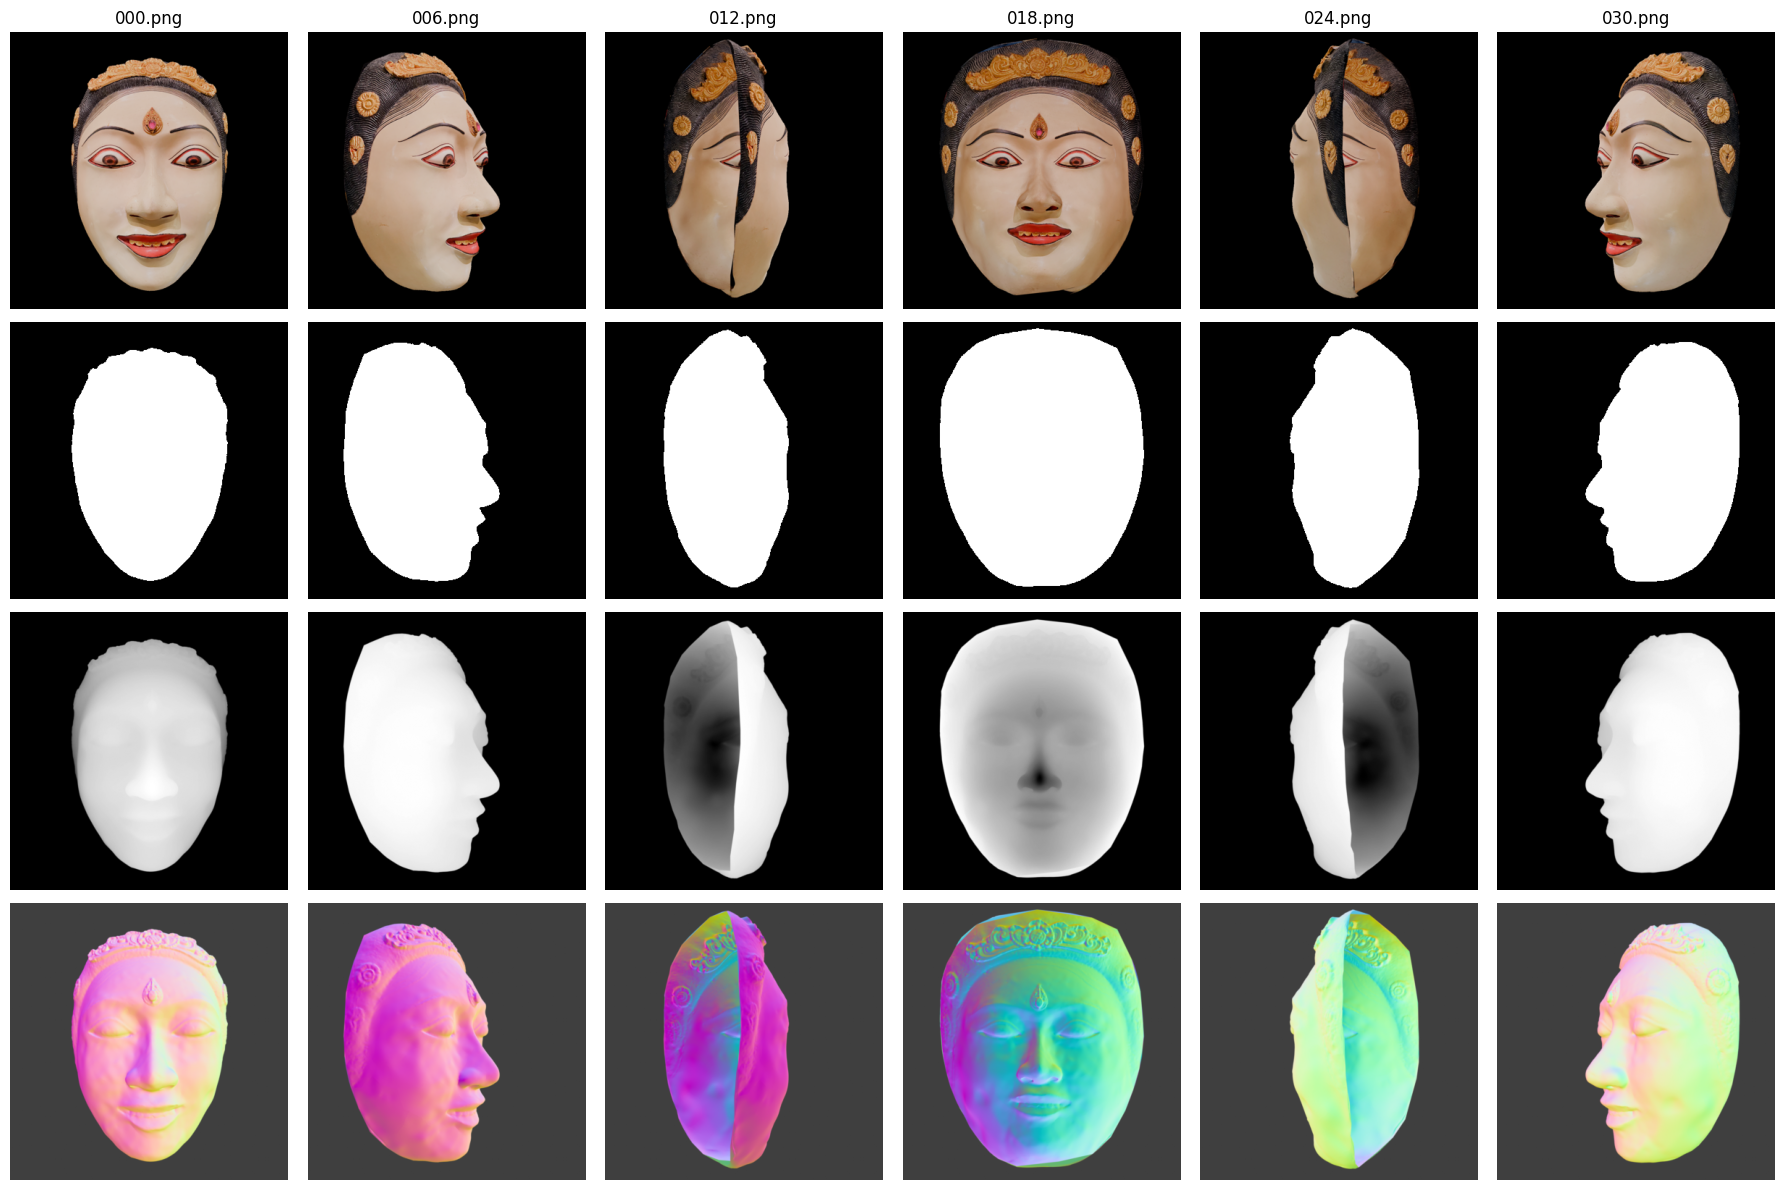

In [11]:
# Cell 10: Visual sanity check — RGB / mask / depth / normal
sample = next(iter(train_loader))
imgs = sample['images'][0]
masks = sample['masks'][0]
depths = sample['depths'][0]
normals = sample['normals'][0]

n = imgs.shape[0]
fig, axes = plt.subplots(4, n, figsize=(3*n, 12))
for i in range(n):
    axes[0, i].imshow(imgs[i].permute(1,2,0).numpy())
    axes[0, i].set_title(sample['view_names'][i][0] if isinstance(sample['view_names'][i], (list, tuple)) else sample['view_names'][i])
    axes[1, i].imshow(masks[i,0].numpy(), cmap='gray')
    axes[2, i].imshow(depths[i,0].numpy(), cmap='gray')
    axes[3, i].imshow(normals[i].permute(1,2,0).numpy())
    for r in range(4):
        axes[r, i].axis('off')
axes[0,0].set_ylabel('RGB')
axes[1,0].set_ylabel('Mask')
axes[2,0].set_ylabel('Depth')
axes[3,0].set_ylabel('Normal')
plt.tight_layout(); plt.show()


In [12]:
# Cell 11: Load pretrained reconstruction model + parameter diagnostics

def load_instantmesh_model(config_path, device):
    config = OmegaConf.load(config_path)
    config_name = os.path.basename(str(config_path)).replace('.yaml', '')
    model = instantiate_from_config(config.model_config)

    if os.path.exists(config.infer_config.model_path):
        model_ckpt_path = config.infer_config.model_path
    else:
        model_ckpt_path = hf_hub_download(
            repo_id='TencentARC/InstantMesh',
            filename=f"{config_name.replace('-', '_')}.ckpt",
            repo_type='model',
        )

    print('Loading:', model_ckpt_path)
    state = torch.load(model_ckpt_path, map_location='cpu')
    state_dict = state['state_dict'] if isinstance(state, dict) and 'state_dict' in state else state
    state_dict = {k[14:]: v for k, v in state_dict.items() if k.startswith('lrm_generator.')}
    model.load_state_dict(state_dict, strict=True)
    model = model.to(device)

    if config_name.startswith('instant-mesh'):
        model.init_flexicubes_geometry(device, fovy=30.0)

    model.float().eval()
    return model, config, config_name

model, config, config_name = load_instantmesh_model(IM_CONFIG, DEVICE)
infer_config = OmegaConf.to_container(config.infer_config, resolve=True)
print('Loaded:', config_name)
print('Params:', sum(p.numel() for p in model.parameters()))

# Diagnostic penting: I2 lama gagal karena nama block tidak match.
def summarize_parameter_names(model, max_tail=80):
    rows = []
    for name, p in model.named_parameters():
        rows.append({'name': name, 'top_module': name.split('.')[0], 'numel': p.numel(), 'shape': tuple(p.shape)})
    df = pd.DataFrame(rows)
    print('Total parameter tensors:', len(df))
    print('Top module summary:')
    display(df.groupby('top_module')['numel'].sum().sort_values(ascending=False).reset_index())
    print(f'Last {max_tail} parameter tensors in model order:')
    display(df.tail(max_tail))
    df.to_csv(LOG_ROOT / 'parameter_name_diagnostics.csv', index=False)
    return df

param_df = summarize_parameter_names(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:90: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/343M [00:00<?, ?B/s]

Some weights of ViTModel were not initialized from the model checkpoint at facebook/dino-vitb16 and are newly initialized: ['encoder.layer.0.adaLN_modulation.1.bias', 'encoder.layer.0.adaLN_modulation.1.weight', 'encoder.layer.1.adaLN_modulation.1.bias', 'encoder.layer.1.adaLN_modulation.1.weight', 'encoder.layer.10.adaLN_modulation.1.bias', 'encoder.layer.10.adaLN_modulation.1.weight', 'encoder.layer.11.adaLN_modulation.1.bias', 'encoder.layer.11.adaLN_modulation.1.weight', 'encoder.layer.2.adaLN_modulation.1.bias', 'encoder.layer.2.adaLN_modulation.1.weight', 'encoder.layer.3.adaLN_modulation.1.bias', 'encoder.layer.3.adaLN_modulation.1.weight', 'encoder.layer.4.adaLN_modulation.1.bias', 'encoder.layer.4.adaLN_modulation.1.weight', 'encoder.layer.5.adaLN_modulation.1.bias', 'encoder.layer.5.adaLN_modulation.1.weight', 'encoder.layer.6.adaLN_modulation.1.bias', 'encoder.layer.6.adaLN_modulation.1.weight', 'encoder.layer.7.adaLN_modulation.1.bias', 'encoder.layer.7.adaLN_modulation.1.w

preprocessor_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

instant_mesh_large.ckpt:   0%|          | 0.00/1.51G [00:00<?, ?B/s]

Loading: /root/.cache/huggingface/hub/models--TencentARC--InstantMesh/snapshots/b785b4ecfb6636ef34a08c748f96f6a5686244d0/instant_mesh_large.ckpt
Loaded: instant-mesh-large
Params: 378657644
Total parameter tensors: 519
Top module summary:


,top_module,numel
0,transformer,263702608
1,encoder,114750720
2,synthesizer,204316


Last 80 parameter tensors in model order:


,name,top_module,numel,shape
439,transformer.layers.13.cross_attn.v_proj_weight,transformer,786432,"(1024, 768)"
440,transformer.layers.13.cross_attn.out_proj.weight,transformer,1048576,"(1024, 1024)"
441,transformer.layers.13.norm2.weight,transformer,1024,"(1024,)"
442,transformer.layers.13.norm2.bias,transformer,1024,"(1024,)"
443,transformer.layers.13.self_attn.in_proj_weight,transformer,3145728,"(3072, 1024)"
...,...,...,...,...
514,synthesizer.decoder.net_weight.2.bias,synthesizer,64,"(64,)"
515,synthesizer.decoder.net_weight.4.weight,synthesizer,4096,"(64, 64)"
516,synthesizer.decoder.net_weight.4.bias,synthesizer,64,"(64,)"
517,synthesizer.decoder.net_weight.6.weight,synthesizer,1344,"(21, 64)"


In [13]:
# Cell 12: Camera + output helpers
def get_input_cameras(batch_size, radius=4.0):
    return get_zero123plus_input_cameras(batch_size=batch_size, radius=radius).to(DEVICE)

def get_render_cameras(batch_size, radius=4.0, elevation=20.0):
    c2ws = get_circular_camera_poses(M=len(SELECT_VIEW_INDICES), radius=radius, elevation=elevation)
    cameras = torch.linalg.inv(c2ws)
    cameras = cameras.unsqueeze(0).repeat(batch_size, 1, 1, 1)
    return cameras.to(DEVICE)

def ensure_bmchw(x):
    if x is None:
        return None
    if x.ndim == 5 and x.shape[-1] in [1, 3, 4]:
        x = x.permute(0, 1, 4, 2, 3).contiguous()
    if x.ndim == 4:
        x = x.unsqueeze(1)
    return x

def normalize_render_output(out):
    """Return dict with optional rgb/mask/depth/normal.
    InstantMesh renderer versions differ. This helper is deliberately permissive.
    If depth/normal are unavailable, training skips those losses and logs NaN/0.
    """
    if not isinstance(out, dict):
        if torch.is_tensor(out):
            return {'rgb': out, 'mask': None, 'depth': None, 'normal': None}
        raise TypeError(type(out))
    result = {'rgb': None, 'mask': None, 'depth': None, 'normal': None}
    for k in ['img', 'image', 'images_rgb', 'rgb', 'comp_rgb']:
        if k in out:
            result['rgb'] = out[k]
            break
    for k in ['mask', 'alpha', 'opacity', 'images_alpha', 'comp_mask', 'weights_sum']:
        if k in out:
            result['mask'] = out[k]
            break
    for k in ['depth', 'images_depth', 'comp_depth', 'z_depth', 'render_depth']:
        if k in out:
            result['depth'] = out[k]
            break
    for k in ['normal', 'normals', 'images_normal', 'comp_normal', 'render_normal']:
        if k in out:
            result['normal'] = out[k]
            break
    if result['rgb'] is None:
        raise KeyError(f'No RGB/image key in renderer output. Keys={list(out.keys())}')
    return result


In [14]:
# Cell 13: Select trainable parameters — Dynamic I2 Improved

def _is_decoder_like(name):
    n = name.lower()
    keys = ['decoder', 'post_processor', 'head', 'density', 'color', 'to_rgb', 'net_sdf', 'net_rgb', 'net_deformation']
    return any(k in n for k in keys)

def _extract_block_index(name):
    n = name.lower()
    patterns = [
        r'(?:transformer|backbone|encoder|triplane|lrm).*?(?:blocks|layers|resblocks|block|layer)\.(\d+)',
        r'(?:blocks|layers|resblocks)\.(\d+)',
        r'\.(\d+)\.(?:attn|mlp|norm|ff|linear)',
    ]
    for pat in patterns:
        m = re.search(pat, n)
        if m:
            return int(m.group(1))
    return None

def print_trainable_summary(model, max_names=40):
    trainable = [(n, p.numel()) for n, p in model.named_parameters() if p.requires_grad]
    total_trainable = sum(v for _, v in trainable)
    total_params = sum(p.numel() for p in model.parameters())
    print('Trainable:', total_trainable, '/', total_params, 'ratio', total_trainable / max(total_params, 1))
    print('Trainable tensors:', len(trainable))
    print('First trainable:')
    for n, v in trainable[:max_names]:
        print('-', n, v)
    if len(trainable) > max_names:
        print('... Last trainable:')
        for n, v in trainable[-10:]:
            print('-', n, v)
    return total_trainable

def set_trainable_params(model, mode='i2_dynamic'):
    for p in model.parameters():
        p.requires_grad = False

    if mode in ['decoder_only', 'i1_decoder']:
        for name, p in model.named_parameters():
            if _is_decoder_like(name):
                p.requires_grad = True
        total = print_trainable_summary(model)
        if total == 0:
            raise RuntimeError('Decoder selector tidak menemukan parameter. Cek parameter_name_diagnostics.csv')
        return total

    if mode in ['decoder_last_blocks', 'i2_dynamic', 'i2_balanced_tail']:
        # 1) Decoder selalu dibuka.
        for name, p in model.named_parameters():
            if _is_decoder_like(name):
                p.requires_grad = True

        # 2) Coba buka block belakang kalau indeks block bisa dideteksi.
        block_to_names = defaultdict(list)
        for name, p in model.named_parameters():
            idx = _extract_block_index(name)
            if idx is not None and not _is_decoder_like(name):
                if 'camera' not in name.lower():
                    block_to_names[idx].append(name)

        if block_to_names:
            all_blocks = sorted(block_to_names.keys())
            selected_blocks = all_blocks[-I2_LAST_N_BLOCKS:]
            selected_name_set = set()
            for bi in selected_blocks:
                selected_name_set.update(block_to_names[bi])
            for name, p in model.named_parameters():
                if name in selected_name_set:
                    p.requires_grad = True
            print('Detected block indices:', all_blocks)
            print('Selected last blocks for I2:', selected_blocks)
        else:
            print('No block indices detected. Using ordered-tail fallback.')

        # 3) Kalau masih sekecil I1, buka parameter paling belakang sampai target minimum.
        total = sum(p.numel() for p in model.parameters() if p.requires_grad)
        if total < I2_TARGET_MIN_TRAINABLE:
            print(f'Trainable masih kecil ({total}). Activating ordered-tail fallback until >= {I2_TARGET_MIN_TRAINABLE}.')
            for name, p in reversed(list(model.named_parameters())):
                if p.requires_grad:
                    continue
                lname = name.lower()
                if any(skip in lname for skip in ['camera_embedder']):
                    continue
                current = sum(pp.numel() for pp in model.parameters() if pp.requires_grad)
                if current >= I2_TARGET_MIN_TRAINABLE:
                    break
                if current >= I2_TARGET_MAX_TRAINABLE:
                    break
                p.requires_grad = True

        total = print_trainable_summary(model)
        if total <= DECODER_ONLY_REFERENCE_PARAMS:
            raise RuntimeError(f'I2 masih hanya {total} trainable params. Selector gagal seperti notebook lama.')
        if total < I2_TARGET_MIN_TRAINABLE:
            print(f'WARNING: trainable {total} masih di bawah target {I2_TARGET_MIN_TRAINABLE}.')
        return total

    raise ValueError(mode)

In [15]:
# Cell 14: RGB + mask + depth + normal loss, with safe fallback if renderer lacks depth/normal

def resize_target_to(pred, target):
    pred = ensure_bmchw(pred)
    target = ensure_bmchw(target)
    b, m, c, h, w = pred.shape
    t = target.reshape(b*m, target.shape[2], target.shape[3], target.shape[4])
    mode = 'nearest' if target.shape[2] == 1 and target.dtype in [torch.uint8, torch.bool] else 'bilinear'
    t = F.interpolate(t.float(), size=(h, w), mode=mode, align_corners=False if mode == 'bilinear' else None)
    return t.reshape(b, m, target.shape[2], h, w)

def masked_l1(pred, target, mask, eps=1e-6):
    pred = ensure_bmchw(pred).float()
    target = ensure_bmchw(target).float()
    mask = ensure_bmchw(mask).float()
    if mask.shape[2] == 1 and pred.shape[2] != 1:
        mask = mask.expand(-1, -1, pred.shape[2], -1, -1)
    return ((pred - target).abs() * mask).sum() / (mask.sum() + eps)

def edge_map(x):
    x = ensure_bmchw(x).float()
    dx = F.pad((x[..., :, 1:] - x[..., :, :-1]).abs(), (0, 1, 0, 0))
    dy = F.pad((x[..., 1:, :] - x[..., :-1, :]).abs(), (0, 0, 0, 1))
    return (dx + dy).clamp(0, 1)

def normal_cosine_loss(pred_normal, target_normal, mask):
    pred_normal = resize_target_to(pred_normal, target_normal).float()
    target_normal = target_normal.float()
    mask = resize_target_to(pred_normal[:, :, :1], mask).float()
    # Convert [0,1] normal maps to [-1,1]
    p = F.normalize(pred_normal * 2.0 - 1.0, dim=2, eps=1e-6)
    t = F.normalize(target_normal * 2.0 - 1.0, dim=2, eps=1e-6)
    cos = (p * t).sum(dim=2, keepdim=True)
    return ((1.0 - cos) * mask).sum() / (mask.sum() + 1e-6)

def make_anchor_state(model):
    anchor = {}
    for name, p in model.named_parameters():
        if p.requires_grad:
            anchor[name] = p.detach().clone().float()
    print('Anchor tensors:', len(anchor), '| params:', sum(v.numel() for v in anchor.values()))
    return anchor

def compute_loss(render_out, target_img, target_mask, target_depth, target_normal, model=None, anchor_state=None):
    pred_img = ensure_bmchw(render_out['rgb'])
    pred_mask = ensure_bmchw(render_out.get('mask'))
    pred_depth = ensure_bmchw(render_out.get('depth'))
    pred_normal = ensure_bmchw(render_out.get('normal'))

    if pred_img.shape[2] == 4:
        if pred_mask is None:
            pred_mask = pred_img[:, :, 3:4]
        pred_img = pred_img[:, :, :3]

    target_img = resize_target_to(pred_img, target_img).float().clamp(0, 1)
    target_mask_for_img = resize_target_to(pred_img[:, :, :1], target_mask).float().clamp(0, 1)

    rgb_fg = masked_l1(pred_img.float(), target_img, target_mask_for_img)
    rgb_bg = masked_l1(pred_img.float(), target_img, 1.0 - target_mask_for_img)

    mask_bce = torch.tensor(0.0, device=pred_img.device)
    mask_edge = torch.tensor(0.0, device=pred_img.device)
    symmetry = torch.tensor(0.0, device=pred_img.device)

    if pred_mask is not None:
        pred_mask = ensure_bmchw(pred_mask)
        if pred_mask.shape[2] != 1:
            pred_mask = pred_mask[:, :, :1]
        target_mask_resized = resize_target_to(pred_mask, target_mask).float().clamp(0, 1)
        pred_mask = pred_mask.float().clamp(1e-5, 1 - 1e-5)
        mask_bce = F.binary_cross_entropy(pred_mask, target_mask_resized)
        mask_edge = F.l1_loss(edge_map(pred_mask), edge_map(target_mask_resized))
        front_pred = pred_mask[:, 0:1]
        symmetry = F.l1_loss(front_pred, torch.flip(front_pred, dims=[-1]))

    depth_loss = torch.tensor(0.0, device=pred_img.device)
    depth_edge_loss = torch.tensor(0.0, device=pred_img.device)
    depth_smooth_loss = torch.tensor(0.0, device=pred_img.device)
    has_depth_loss = False
    if pred_depth is not None:
        if pred_depth.shape[2] != 1:
            pred_depth = pred_depth[:, :, :1]
        pred_depth = pred_depth.float().clamp(0, 1)
        target_depth_resized = resize_target_to(pred_depth, target_depth).float().clamp(0, 1)
        target_mask_depth = resize_target_to(pred_depth, target_mask).float().clamp(0, 1)
        depth_loss = masked_l1(pred_depth, target_depth_resized, target_mask_depth)
        depth_edge_loss = masked_l1(edge_map(pred_depth), edge_map(target_depth_resized), target_mask_depth)
        depth_smooth_loss = (edge_map(pred_depth) * target_mask_depth).mean()
        has_depth_loss = True

    normal_loss = torch.tensor(0.0, device=pred_img.device)
    normal_edge_loss = torch.tensor(0.0, device=pred_img.device)
    has_normal_loss = False
    if pred_normal is not None:
        if pred_normal.shape[2] >= 3:
            pred_normal = pred_normal[:, :, :3].float().clamp(0, 1)
            normal_loss = normal_cosine_loss(pred_normal, target_normal, target_mask)
            target_normal_resized = resize_target_to(pred_normal, target_normal).float().clamp(0, 1)
            target_mask_normal = resize_target_to(pred_normal[:, :, :1], target_mask).float().clamp(0, 1)
            normal_edge_loss = masked_l1(edge_map(pred_normal), edge_map(target_normal_resized), target_mask_normal)
            has_normal_loss = True

    anchor_loss = torch.tensor(0.0, device=pred_img.device)
    if model is not None and anchor_state is not None and ANCHOR_LOSS_WEIGHT > 0:
        vals = []
        for name, p in model.named_parameters():
            if p.requires_grad and name in anchor_state:
                vals.append((p.float() - anchor_state[name]).pow(2).mean())
        if vals:
            anchor_loss = torch.stack(vals).mean()

    loss = (
        RGB_FG_LOSS_WEIGHT * rgb_fg +
        RGB_BG_LOSS_WEIGHT * rgb_bg +
        MASK_LOSS_WEIGHT * mask_bce +
        MASK_EDGE_LOSS_WEIGHT * mask_edge +
        DEPTH_LOSS_WEIGHT * depth_loss +
        DEPTH_EDGE_LOSS_WEIGHT * depth_edge_loss +
        DEPTH_SMOOTH_LOSS_WEIGHT * depth_smooth_loss +
        NORMAL_LOSS_WEIGHT * normal_loss +
        NORMAL_EDGE_LOSS_WEIGHT * normal_edge_loss +
        SYMMETRY_LOSS_WEIGHT * symmetry +
        ANCHOR_LOSS_WEIGHT * anchor_loss
    )

    return loss, {
        'loss': float(loss.detach().cpu()),
        'rgb_fg_l1': float(rgb_fg.detach().cpu()),
        'rgb_bg_l1': float(rgb_bg.detach().cpu()),
        'mask_bce': float(mask_bce.detach().cpu()),
        'mask_edge': float(mask_edge.detach().cpu()),
        'depth_l1': float(depth_loss.detach().cpu()),
        'depth_edge': float(depth_edge_loss.detach().cpu()),
        'depth_smooth': float(depth_smooth_loss.detach().cpu()),
        'normal_cos_loss': float(normal_loss.detach().cpu()),
        'normal_edge': float(normal_edge_loss.detach().cpu()),
        'has_depth_loss': float(has_depth_loss),
        'has_normal_loss': float(has_normal_loss),
        'symmetry': float(symmetry.detach().cpu()),
        'anchor': float(anchor_loss.detach().cpu()),
    }

def train_one_batch(model, batch, optimizer=None, scaler=None, train=True, anchor_state=None):
    images = batch['images'].to(DEVICE).float()
    masks = batch['masks'].to(DEVICE).float()
    depths = batch['depths'].to(DEVICE).float()
    normals = batch['normals'].to(DEVICE).float()
    b = images.shape[0]

    input_cams = get_input_cameras(b).float()
    render_cams = get_render_cameras(b).float()

    model = model.float()
    model.train(train)

    with torch.set_grad_enabled(train):
        planes = model.forward_planes(images, input_cams).float()
        out = model.forward_geometry(planes, render_cams, render_size=RENDER_SIZE)
        render_out = normalize_render_output(out)
        loss, logs = compute_loss(render_out, images, masks, depths, normals, model=model if train else None, anchor_state=anchor_state if train else None)

    if train:
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], max_norm=GRAD_CLIP_NORM)
        optimizer.step()

    return logs


In [16]:
# Cell 15: Metric helpers for mesh validation / final evaluation

def _to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    if hasattr(x, 'detach'):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def save_obj_vertex_color(vertices, faces, colors, fpath):
    vertices = _to_numpy(vertices).astype(np.float32)
    faces = _to_numpy(faces).astype(np.int64)
    if vertices.ndim == 3:
        vertices = vertices[0]
    if faces.ndim == 3:
        faces = faces[0]
    if colors is None:
        colors = np.ones_like(vertices, dtype=np.float32)
    colors = _to_numpy(colors)
    if colors.ndim == 3:
        colors = colors[0]
    if colors.shape[0] != vertices.shape[0]:
        colors = np.ones_like(vertices, dtype=np.float32)

    # Samakan orientasi dengan runner InstantMesh baseline.
    vertices = vertices @ np.array([[1, 0, 0], [0, 1, 0], [0, 0, -1]], dtype=np.float32)
    faces = faces[:, [2, 1, 0]]

    mesh = trimesh.Trimesh(vertices=vertices, faces=faces, vertex_colors=colors, process=False)
    Path(fpath).parent.mkdir(parents=True, exist_ok=True)
    mesh.export(str(fpath), 'obj')
    return fpath

def load_mesh_safe(mesh_path: Path):
    mesh = trimesh.load(mesh_path, force='mesh', process=False)
    if isinstance(mesh, trimesh.Scene):
        mesh = trimesh.util.concatenate(tuple(g for g in mesh.geometry.values()))
    return mesh

def sample_points_from_mesh(mesh_path: Path, n=8000, seed=42):
    np.random.seed(seed)
    mesh = load_mesh_safe(mesh_path)
    pts, _ = trimesh.sample.sample_surface(mesh, n)
    return np.asarray(pts, dtype=np.float32)

def nearest_dist(a, b):
    tree = cKDTree(b)
    d, _ = tree.query(a, k=1)
    return d

def chamfer_distance(a, b):
    d_ab = nearest_dist(a, b)
    d_ba = nearest_dist(b, a)
    return float(d_ab.mean() + d_ba.mean())

def uniform_hausdorff_distance(a, b):
    d_ab = nearest_dist(a, b)
    d_ba = nearest_dist(b, a)
    return float(max(d_ab.max(), d_ba.max()))

def wasserstein_safe(dgm1, dgm2, p=1):
    sig = inspect.signature(wasserstein)
    kwargs = {}
    if 'matching' in sig.parameters:
        kwargs['matching'] = False
    if 'p' in sig.parameters:
        kwargs['p'] = p
    elif 'order' in sig.parameters:
        kwargs['order'] = p
    return wasserstein(dgm1, dgm2, **kwargs)

def filter_finite_dgm(dgm):
    dgm = np.asarray(dgm)
    if dgm.size == 0:
        return dgm
    mask = np.isfinite(dgm[:, 0]) & np.isfinite(dgm[:, 1])
    return dgm[mask]

def tmd_distance(points_pred, points_gt, maxdim=1, thresh=1.5, p=1):
    dg_pred = ripser(points_pred, maxdim=maxdim, thresh=thresh)['dgms']
    dg_gt = ripser(points_gt, maxdim=maxdim, thresh=thresh)['dgms']
    dist = 0.0
    for dim in range(maxdim + 1):
        d1 = filter_finite_dgm(dg_pred[dim])
        d2 = filter_finite_dgm(dg_gt[dim])
        dist += float(wasserstein_safe(d1, d2, p=p))
    return float(dist)

def normalized_mesh_score(cd, uhd, tmd=np.nan):
    """I4 checkpoint score: TMD-heavy to avoid topology-noisy checkpoints.
    Lower is better. Values are normalized by pretrained baseline.
    """
    cd_s = cd / PRETRAINED_REF['cd'] if np.isfinite(cd) else 999
    uhd_s = uhd / PRETRAINED_REF['uhd'] if np.isfinite(uhd) else 999
    if np.isfinite(tmd):
        tmd_s = tmd / PRETRAINED_REF['tmd']
        return float(0.30 * cd_s + 0.15 * uhd_s + 0.55 * tmd_s)
    # If TMD is missing, don't let it dominate checkpointing.
    # This fallback is intentionally conservative.
    return float(0.45 * cd_s + 0.35 * uhd_s + 0.20 * 10.0)

In [17]:
# Cell 16: Checkpoint utilities

def save_stage_checkpoint(model, path, stage, epoch, metrics=None, trainable_params=None):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        'model_state_dict': model.state_dict(),
        'stage': stage,
        'epoch': int(epoch),
        'metrics': metrics or {},
        'trainable_params': trainable_params,
        'config_name': config_name,
        'select_view_indices': SELECT_VIEW_INDICES,
        'train_image_size': TRAIN_IMAGE_SIZE,
        'render_size': RENDER_SIZE,
    }
    torch.save(payload, path)
    print('Saved checkpoint:', path)

def load_stage_checkpoint(model, path, strict=False):
    path = Path(path)
    if not path.exists():
        print('Checkpoint not found:', path)
        return model
    payload = torch.load(path, map_location='cpu')
    state = payload['model_state_dict'] if isinstance(payload, dict) and 'model_state_dict' in payload else payload
    missing, unexpected = model.load_state_dict(state, strict=strict)
    print('Loaded checkpoint:', path)
    print('missing:', len(missing), 'unexpected:', len(unexpected))
    return model

def find_first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None

I1_CKPT_CANDIDATES = [
    PROJECT_ROOT / 'Outputs' / 'instantmesh_finetune_balimask_I123' / 'checkpoints' / 'instantmesh_I1.pt',
    PROJECT_ROOT / 'Outputs' / 'instantmesh_finetune_balimask_I2' / 'checkpoints' / 'instantmesh_I1.pt',
    PROJECT_ROOT / 'Outputs' / 'instantmesh_finetune_balimask_I1' / 'checkpoints' / 'instantmesh_I1.pt',
]
I1_START_CKPT = find_first_existing(I1_CKPT_CANDIDATES)
print('I1_START_CKPT:', I1_START_CKPT)

I1_START_CKPT: /content/drive/MyDrive/Tugas_Akhir/Outputs/instantmesh_finetune_balimask_I123/checkpoints/instantmesh_I1.pt


In [18]:
# Cell 17: Validation helpers
@torch.no_grad()
def validate_model(model, loader, max_batches=None):
    model.eval().float()
    rows = []
    for bi, batch in enumerate(tqdm(loader, desc='val photometric')):
        if max_batches is not None and bi >= max_batches:
            break
        logs = train_one_batch(model, batch, train=False, anchor_state=None)
        rows.append({'batch': bi, 'mask_id': batch['mask_id'][0], **logs})
    return pd.DataFrame(rows)

@torch.no_grad()
def extract_mesh_for_batch(model, batch, out_obj_path):
    model.eval().float()
    images = batch['images'].to(DEVICE).float()
    b = images.shape[0]
    if b != 1:
        raise ValueError('mesh validation expects batch_size=1')
    input_cams = get_input_cameras(b).float()
    planes = model.forward_planes(images, input_cams).float()
    mesh_out = model.extract_mesh(planes, use_texture_map=False, **infer_config)
    vertices, faces, vertex_colors = mesh_out
    return save_obj_vertex_color(vertices, faces, vertex_colors, out_obj_path)

@torch.no_grad()
def validate_mesh(model, loader, stage, epoch, max_objects=3, compute_tmd=False):
    rows = []
    mesh_out_dir = MESHVAL_ROOT / stage / f'epoch_{epoch:03d}'
    mesh_out_dir.mkdir(parents=True, exist_ok=True)
    for bi, batch in enumerate(tqdm(loader, desc=f'meshval {stage} ep{epoch}')):
        if bi >= max_objects:
            break
        mask_id = str(batch['mask_id'][0])
        pred_obj = mesh_out_dir / f'{mask_id}_pred.obj'
        gt_obj = Path(batch['gt_mesh_path'][0])
        rec = {'stage': stage, 'epoch': int(epoch), 'mask_id': mask_id, 'pred_mesh_path': str(pred_obj), 'gt_mesh_path': str(gt_obj), 'ok': False, 'cd': np.nan, 'uhd': np.nan, 'tmd': np.nan}
        try:
            extract_mesh_for_batch(model, batch, pred_obj)
            pred_pts = sample_points_from_mesh(pred_obj, MESHVAL_N_CD, seed=SEED + epoch + bi)
            gt_pts = sample_points_from_mesh(gt_obj, MESHVAL_N_CD, seed=SEED + epoch + bi + 1000)
            rec['cd'] = chamfer_distance(pred_pts, gt_pts)
            rec['uhd'] = uniform_hausdorff_distance(pred_pts, gt_pts)
            if compute_tmd:
                pred_tmd = sample_points_from_mesh(pred_obj, MESHVAL_N_TMD, seed=SEED + epoch + bi + 2000)
                gt_tmd = sample_points_from_mesh(gt_obj, MESHVAL_N_TMD, seed=SEED + epoch + bi + 3000)
                rec['tmd'] = tmd_distance(pred_tmd, gt_tmd, maxdim=TMD_MAXDIM, thresh=TMD_THRESH)
            rec['score'] = normalized_mesh_score(rec['cd'], rec['uhd'], rec['tmd'])
            rec['ok'] = True
        except Exception as e:
            rec['error'] = str(e)
        rows.append(rec)
    df = pd.DataFrame(rows)
    df.to_csv(mesh_out_dir / 'meshval_rows.csv', index=False)
    return df

In [19]:
# Cell 18: Stage training function — mesh-guided checkpointing

def aggregate_logs(logs):
    keys = sorted(set().union(*[x.keys() for x in logs])) if logs else []
    return {k: float(np.nanmean([x[k] for x in logs if k in x])) for k in keys}

def make_optimizer(model):
    decoder_params, body_params = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if _is_decoder_like(name):
            decoder_params.append(p)
        else:
            body_params.append(p)
    groups = []
    if decoder_params:
        groups.append({'params': decoder_params, 'lr': LR_DECODER, 'weight_decay': WEIGHT_DECAY})
    if body_params:
        groups.append({'params': body_params, 'lr': LR_BODY, 'weight_decay': WEIGHT_DECAY})
    print('Optimizer groups: decoder tensors=', len(decoder_params), 'body tensors=', len(body_params))
    print('LR decoder:', LR_DECODER, '| LR body:', LR_BODY)
    return torch.optim.AdamW(groups)

def run_stage(stage_name, epochs, train_mode, ckpt_in=None):
    global model
    print('=' * 90)
    print('STAGE', stage_name, '| mode:', train_mode, '| epochs:', epochs)
    print('ckpt_in:', ckpt_in)
    print('=' * 90)

    if ckpt_in is not None and Path(ckpt_in).exists():
        model = load_stage_checkpoint(model, ckpt_in, strict=False).to(DEVICE)
    else:
        print('No ckpt_in used. Starting from current model state.')

    trainable_params = set_trainable_params(model, train_mode)
    anchor_state = make_anchor_state(model)
    optimizer = make_optimizer(model)

    history = []
    best_score = float('inf')
    best_cd = float('inf')
    best_tmd = float('inf')
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_logs = []
        model.train().float()
        for batch in tqdm(train_loader, desc=f'{stage_name} epoch {epoch}'):
            logs = train_one_batch(model, batch, optimizer=optimizer, train=True, anchor_state=anchor_state)
            train_logs.append(logs)

        train_agg = aggregate_logs(train_logs)
        val_df = validate_model(model, val_loader, max_batches=None)
        val_agg = {f'val_{k}': float(val_df[k].mean()) for k in val_df.columns if k not in ['batch', 'mask_id'] and pd.api.types.is_numeric_dtype(val_df[k])}

        compute_tmd = (epoch % MESHVAL_TMD_EVERY == 0) or (epoch == epochs)
        meshval_df = validate_mesh(model, val_loader, stage_name, epoch, max_objects=MESHVAL_MAX_OBJECTS, compute_tmd=compute_tmd)
        mesh_ok = meshval_df[meshval_df['ok'] == True].copy()
        mesh_agg = {
            'meshval_cd': float(mesh_ok['cd'].mean()) if len(mesh_ok) else np.nan,
            'meshval_uhd': float(mesh_ok['uhd'].mean()) if len(mesh_ok) else np.nan,
            'meshval_tmd': float(mesh_ok['tmd'].mean()) if len(mesh_ok) and mesh_ok['tmd'].notna().any() else np.nan,
        }
        mesh_agg['meshval_score'] = normalized_mesh_score(mesh_agg['meshval_cd'], mesh_agg['meshval_uhd'], mesh_agg['meshval_tmd'])

        rec = {'stage': stage_name, 'epoch': epoch, 'time_sec': time.time() - t0, 'trainable_params': trainable_params, **{f'train_{k}': v for k, v in train_agg.items()}, **val_agg, **mesh_agg}
        history.append(rec)
        pd.DataFrame(history).to_csv(LOG_ROOT / f'history_{stage_name}.csv', index=False)
        print('Epoch record:')
        print(json.dumps({k: (round(v, 6) if isinstance(v, float) and np.isfinite(v) else v) for k, v in rec.items()}, indent=2))

        save_stage_checkpoint(model, CKPT_ROOT / f'{stage_name}_epoch_{epoch:03d}.pt', stage_name, epoch, rec, trainable_params)

        score = rec.get('meshval_score', np.nan)
        cd = rec.get('meshval_cd', np.nan)
        improved = False
        if np.isfinite(score) and score < best_score:
            best_score = score
            save_stage_checkpoint(model, CKPT_ROOT / f'best_meshval_combined_{stage_name}.pt', stage_name, epoch, rec, trainable_params)
            improved = True
        if np.isfinite(cd) and cd < best_cd:
            best_cd = cd
            save_stage_checkpoint(model, CKPT_ROOT / f'best_meshval_cd_{stage_name}.pt', stage_name, epoch, rec, trainable_params)
            improved = True

        tmd = rec.get('meshval_tmd', np.nan)
        if np.isfinite(tmd) and tmd < best_tmd:
            best_tmd = tmd
            save_stage_checkpoint(model, CKPT_ROOT / f'best_meshval_tmd_{stage_name}.pt', stage_name, epoch, rec, trainable_params)
            improved = True

        save_stage_checkpoint(model, CKPT_ROOT / f'last_{stage_name}.pt', stage_name, epoch, rec, trainable_params)

        if improved:
            bad_epochs = 0
        else:
            bad_epochs += 1
            print('No mesh improvement. bad_epochs =', bad_epochs)
        if bad_epochs >= EARLY_STOP_PATIENCE:
            print('Early stopping triggered.')
            break

    return pd.DataFrame(history)

In [20]:
# Cell 19: Run selected stage — I4_topology_aware_max
all_histories = []

SOURCE_CKPT = find_first_existing(PREV_CKPT_PRIORITY)
print('SOURCE_CKPT for I4:', SOURCE_CKPT)
if SOURCE_CKPT is None:
    print('[WARN] No previous I2/I3 checkpoint found. I4 will start from the currently loaded pretrained model.')

if RUN_STAGE_I4:
    hist = run_stage('I4_topology_aware_max', I4_EPOCHS, train_mode='decoder_last_blocks', ckpt_in=SOURCE_CKPT)
    all_histories.append(hist)
else:
    print('RUN_STAGE_I4=False')

hist_all = pd.concat(all_histories, ignore_index=True) if all_histories else pd.DataFrame()
hist_all.to_csv(LOG_ROOT / 'history_all_stages.csv', index=False)
display(hist_all.tail() if len(hist_all) else hist_all)


SOURCE_CKPT for I4: /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I3_trainable_plus_supervision_v1/checkpoints/best_meshval_combined_I3_trainable_plus_supervision.pt
STAGE I4_topology_aware_max | mode: decoder_last_blocks | epochs: 18
ckpt_in: /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I3_trainable_plus_supervision_v1/checkpoints/best_meshval_combined_I3_trainable_plus_supervision.pt
Loaded checkpoint: /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I3_trainable_plus_supervision_v1/checkpoints/best_meshval_combined_I3_trainable_plus_supervision.pt
missing: 0 unexpected: 0
Detected block indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Selected last blocks for I2: [15]
Trainable: 16468508 / 378657644 ratio 0.043491814468691936
Trainable tensors: 48
First trainable:
- transformer.layers.15.norm1.weight 1024
- transformer.layers.15.norm1.bias 1024
- transformer.layer

I4_topology_aware_max epoch 1:   0%|          | 0/21 [00:00<?, ?it/s]

/content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/src/models/geometry/render/neural_render.py:51: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)
  face_normals = torch.cross(v1 - v0, v2 - v0)


val photometric:   0%|          | 0/3 [00:00<?, ?it/s]

meshval I4_topology_aware_max ep1:   0%|          | 0/3 [00:00<?, ?it/s]

...

I4_topology_aware_max epoch 8:   0%|          | 0/21 [00:00<?, ?it/s]

val photometric:   0%|          | 0/3 [00:00<?, ?it/s]

meshval I4_topology_aware_max ep8:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch record:
{
  "stage": "I4_topology_aware_max",
  "epoch": 8,
  "time_sec": 98.239312,
  "trainable_params": 16468508,
  "train_anchor": 0.0,
  "train_depth_edge": 0.016552,
  "train_depth_l1": 0.176981,
  "train_depth_smooth": 0.0,
  "train_has_depth_loss": 1.0,
  "train_has_normal_loss": 1.0,
  "train_loss": 15.535121,
  "train_mask_bce": 8.596855,
  "train_mask_edge": 0.009076,
  "train_normal_cos_loss": 0.0,
  "train_normal_edge": 0.047883,
  "train_rgb_bg_l1": 0.207074,
  "train_rgb_fg_l1": 0.321377,
  "train_symmetry": 0.000123,
  "val_loss": 15.635482,
  "val_rgb_fg_l1": 0.285342,
  "val_rgb_bg_l1": 0.23471,
  "val_mask_bce": 8.673833,
  "val_mask_edge": 0.009433,
  "val_depth_l1": 0.165711,
  "val_depth_edge": 0.019384,
  "val_depth_smooth": 0.0,
  "val_normal_cos_loss": 0.0,
  "val_normal_edge": 0.053234,
  "val_has_depth_loss": 1.0,
  "val_has_normal_loss": 1.0,
  "val_symmetry": 0.000122,
  "val_anchor": 0.0,
  "meshval_cd": 1.217604,
  "meshval_uhd": 1.298449,
  "meshva

,stage,epoch,time_sec,trainable_params,train_anchor,train_depth_edge,train_depth_l1,train_depth_smooth,train_has_depth_loss,train_has_normal_loss,...,val_normal_cos_loss,val_normal_edge,val_has_depth_loss,val_has_normal_loss,val_symmetry,val_anchor,meshval_cd,meshval_uhd,meshval_tmd,meshval_score
3,I4_topology_aware_max,4,181.538001,16468508,6.037464e-09,0.016531,0.176755,0.0,1.0,1.0,...,3.541024e-09,0.054101,1.0,1.0,0.000263,0.0,1.147914,1.282239,70.141455,7.001377
4,I4_topology_aware_max,5,205.532589,16468508,1.020794e-08,0.016425,0.178294,0.0,1.0,1.0,...,3.541024e-09,0.053509,1.0,1.0,0.000251,0.0,1.161419,1.286373,70.175805,7.012637
5,I4_topology_aware_max,6,183.201196,16468508,1.566580e-08,0.016440,0.179094,0.0,1.0,1.0,...,3.541024e-09,0.053075,1.0,1.0,0.000220,0.0,1.179865,1.291362,70.671908,7.067121
6,I4_topology_aware_max,7,135.681561,16468508,2.249692e-08,0.016463,0.177718,0.0,1.0,1.0,...,3.541024e-09,0.053005,1.0,1.0,0.000134,0.0,1.212651,1.294036,70.398967,7.061964
7,I4_topology_aware_max,8,98.239312,16468508,3.098859e-08,0.016552,0.176981,0.0,1.0,1.0,...,3.541024e-09,0.053234,1.0,1.0,0.000122,0.0,1.217604,1.298449,70.831994,7.103351


,stage,epoch,time_sec,trainable_params,train_anchor,train_depth_edge,train_depth_l1,train_depth_smooth,train_has_depth_loss,train_has_normal_loss,...,val_normal_cos_loss,val_normal_edge,val_has_depth_loss,val_has_normal_loss,val_symmetry,val_anchor,meshval_cd,meshval_uhd,meshval_tmd,meshval_score
0,I4_topology_aware_max,1,285.870786,16468508,1.601362e-10,0.016580,0.179137,0.0,1.0,1.0,...,3.541024e-09,0.053626,1.0,1.0,0.000522,0.0,1.086755,1.276899,70.586162,7.005303
1,I4_topology_aware_max,2,230.624039,16468508,1.098143e-09,0.016426,0.177745,0.0,1.0,1.0,...,3.541024e-09,0.054076,1.0,1.0,0.000226,0.0,1.112805,1.280033,69.248726,6.903537
2,I4_topology_aware_max,3,274.989887,16468508,3.029703e-09,0.016587,0.177663,0.0,1.0,1.0,...,3.541024e-09,0.054516,1.0,1.0,0.000251,0.0,1.131787,1.290136,69.775302,6.961935
3,I4_topology_aware_max,4,181.538001,16468508,6.037464e-09,0.016531,0.176755,0.0,1.0,1.0,...,3.541024e-09,0.054101,1.0,1.0,0.000263,0.0,1.147914,1.282239,70.141455,7.001377
4,I4_topology_aware_max,5,205.532589,16468508,1.020794e-08,0.016425,0.178294,0.0,1.0,1.0,...,3.541024e-09,0.053509,1.0,1.0,0.000251,0.0,1.161419,1.286373,70.175805,7.012637
5,I4_topology_aware_max,6,183.201196,16468508,1.566580e-08,0.016440,0.179094,0.0,1.0,1.0,...,3.541024e-09,0.053075,1.0,1.0,0.000220,0.0,1.179865,1.291362,70.671908,7.067121
6,I4_topology_aware_max,7,135.681561,16468508,2.249692e-08,0.016463,0.177718,0.0,1.0,1.0,...,3.541024e-09,0.053005,1.0,1.0,0.000134,0.0,1.212651,1.294036,70.398967,7.061964
7,I4_topology_aware_max,8,98.239312,16468508,3.098859e-08,0.016552,0.176981,0.0,1.0,1.0,...,3.541024e-09,0.053234,1.0,1.0,0.000122,0.0,1.217604,1.298449,70.831994,7.103351


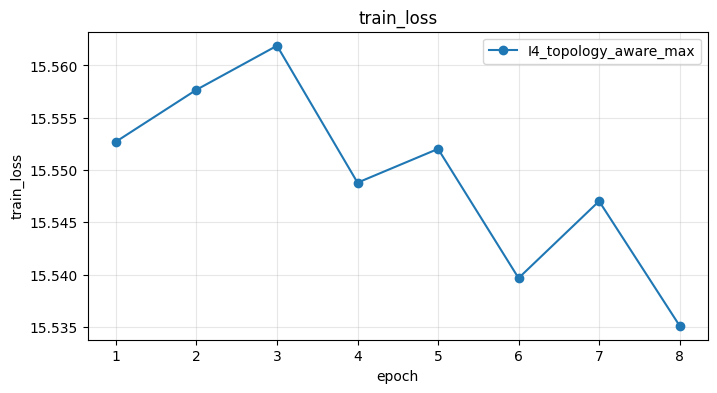

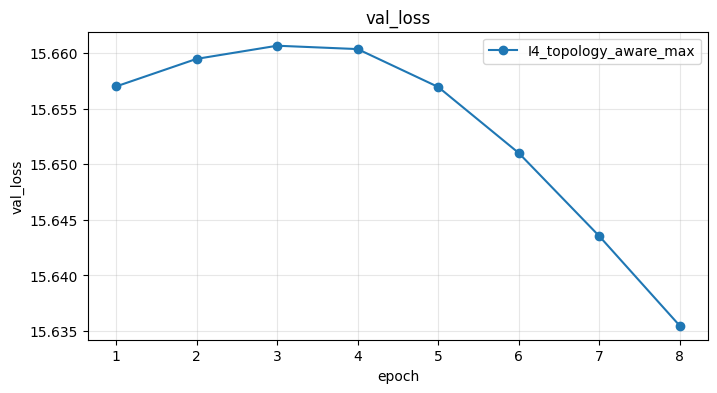

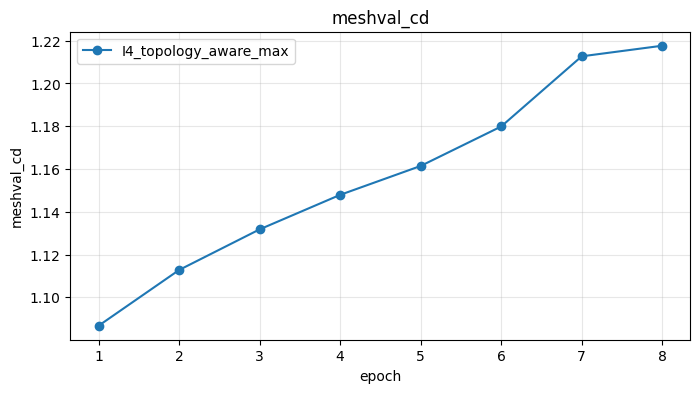

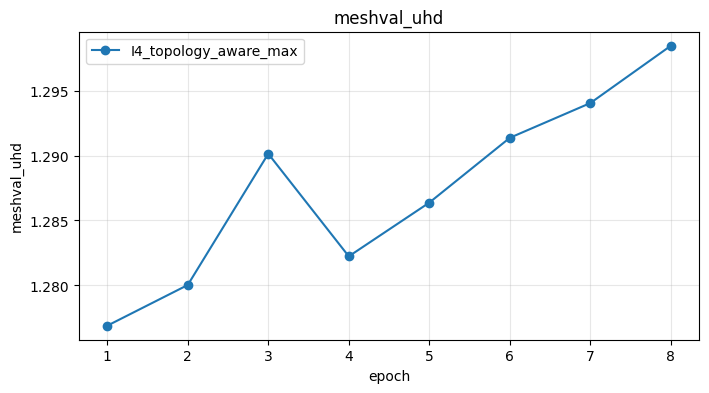

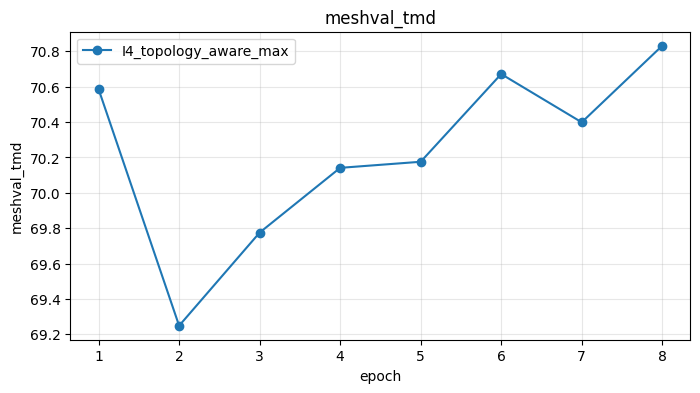

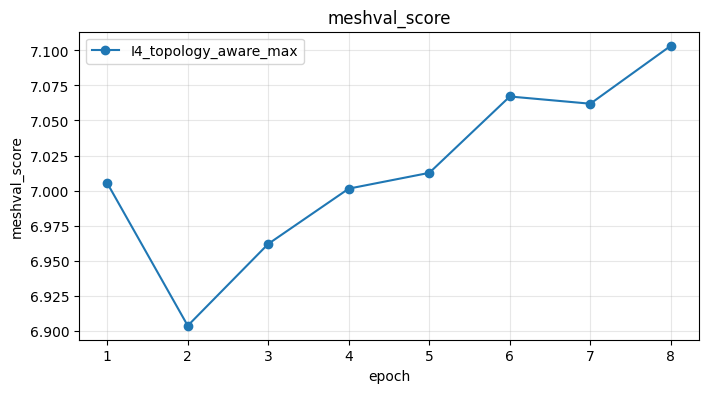

In [21]:
# Cell 20: Plot training history
history_csv = LOG_ROOT / 'history_all_stages.csv'
if history_csv.exists():
    hist = pd.read_csv(history_csv)
    display(hist)
    for col in ['train_loss', 'val_loss', 'meshval_cd', 'meshval_uhd', 'meshval_tmd', 'meshval_score']:
        if col in hist.columns and hist[col].notna().any():
            plt.figure(figsize=(8, 4))
            for stage, g in hist.groupby('stage'):
                plt.plot(g['epoch'], g[col], marker='o', label=stage)
            plt.title(col)
            plt.xlabel('epoch')
            plt.ylabel(col)
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()
else:
    print('History belum tersedia.')

In [22]:
# Cell 21: Select final checkpoint + save training summary
CHECKPOINT_PRIORITY = [
    CKPT_ROOT / 'best_meshval_tmd_I4_topology_aware_max.pt',
    CKPT_ROOT / 'best_meshval_combined_I4_topology_aware_max.pt',
    CKPT_ROOT / 'best_meshval_cd_I4_topology_aware_max.pt',
    CKPT_ROOT / 'last_I4_topology_aware_max.pt',
]
SELECTED_FT_CKPT = find_first_existing(CHECKPOINT_PRIORITY)
print('SELECTED_FT_CKPT:', SELECTED_FT_CKPT)
if SELECTED_FT_CKPT is None:
    raise FileNotFoundError('Belum ada checkpoint I4. Jalankan training stage dulu.')

summary = {
    'strategy': 'I4_topology_aware_max',
    'out_root': str(OUT_ROOT),
    'source_ckpt': str(SOURCE_CKPT) if 'SOURCE_CKPT' in globals() and SOURCE_CKPT else '',
    'selected_ft_ckpt': str(SELECTED_FT_CKPT),
    'metadata_csv': str(METADATA_CSV),
    'select_view_indices': SELECT_VIEW_INDICES,
    'train_view_sets': TRAIN_VIEW_SETS,
    'train_image_size': TRAIN_IMAGE_SIZE,
    'render_size': RENDER_SIZE,
    'target_trainable_min': I2_TARGET_MIN_TRAINABLE,
    'target_trainable_max': I2_TARGET_MAX_TRAINABLE,
    'loss_weights': {
        'rgb_fg': RGB_FG_LOSS_WEIGHT,
        'rgb_bg': RGB_BG_LOSS_WEIGHT,
        'mask': MASK_LOSS_WEIGHT,
        'mask_edge': MASK_EDGE_LOSS_WEIGHT,
        'depth': DEPTH_LOSS_WEIGHT,
        'depth_edge': DEPTH_EDGE_LOSS_WEIGHT,
        'depth_smooth': DEPTH_SMOOTH_LOSS_WEIGHT,
        'normal': NORMAL_LOSS_WEIGHT,
        'normal_edge': NORMAL_EDGE_LOSS_WEIGHT,
        'symmetry': SYMMETRY_LOSS_WEIGHT,
        'anchor': ANCHOR_LOSS_WEIGHT,
    },
    'checkpoint_priority': [str(p) for p in CHECKPOINT_PRIORITY],
}
(OUT_ROOT / 'selected_checkpoint_summary.json').write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))


SELECTED_FT_CKPT: /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I4_topology_aware_max_v1/checkpoints/best_meshval_tmd_I4_topology_aware_max.pt
{
  "strategy": "I4_topology_aware_max",
  "out_root": "/content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I4_topology_aware_max_v1",
  "source_ckpt": "/content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I3_trainable_plus_supervision_v1/checkpoints/best_meshval_combined_I3_trainable_plus_supervision.pt",
  "selected_ft_ckpt": "/content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I4_topology_aware_max_v1/checkpoints/best_meshval_tmd_I4_topology_aware_max.pt",
  "metadata_csv": "/content/drive/MyDrive/Tugas_Akhir/Dataset/BaliMask3D/metadata/balimask3d_bali36_rgb_mask_depth_normal_exact_rgb_setup_split_COLAB.csv",
  "select_view_indices": [
    0,
    6,
    12,
    18,
    24,
    30
  ],
  "train_view_sets": [
    [
      

# Evaluation + Inference from Fine-Tuned Checkpoint

Bagian ini dijalankan setelah fine-tuning I1/I2/I3.

Alur:
1. pilih checkpoint, default prioritas: I3 > I2 > I1 > pretrained
2. tulis runner inference khusus fine-tuned checkpoint
3. build RGBA input untuk `split == test`
4. inference test-only
5. evaluasi CD / UHD / TMD
6. tampilkan 3 best, 3 worst, dan front view showcase


In [23]:
from pathlib import Path

print("CKPT_ROOT:", CKPT_ROOT)
print("Exists:", CKPT_ROOT.exists())

if CKPT_ROOT.exists():
    for p in sorted(CKPT_ROOT.glob("*")):
        print(p.name, p.stat().st_size)

CKPT_ROOT: /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I4_topology_aware_max_v1/checkpoints
Exists: True
I4_topology_aware_max_epoch_001.pt 1514852073
I4_topology_aware_max_epoch_002.pt 1514852073
I4_topology_aware_max_epoch_003.pt 1514852073
I4_topology_aware_max_epoch_004.pt 1514852073
I4_topology_aware_max_epoch_005.pt 1514852073
I4_topology_aware_max_epoch_006.pt 1514852073
I4_topology_aware_max_epoch_007.pt 1514852073
I4_topology_aware_max_epoch_008.pt 1514852073
best_meshval_cd_I4_topology_aware_max.pt 1514855223
best_meshval_combined_I4_topology_aware_max.pt 1514858373
best_meshval_tmd_I4_topology_aware_max.pt 1514855748
last_I4_topology_aware_max.pt 1514849448


In [24]:
# Cell 22: Fine-tuned inference configuration
# Jalankan setelah training stage selesai.

FT_INFER_ROOT = OUT_ROOT / 'finetuned_inference'
FT_RGBA_ROOT = FT_INFER_ROOT / 'rgba_inputs'
FT_PRED_ROOT = FT_INFER_ROOT / 'pred_meshes'
FT_EVAL_ROOT = FT_INFER_ROOT / 'evaluation'
FT_SHOWCASE_ROOT = FT_INFER_ROOT / 'showcase'
FT_LOG_ROOT = FT_INFER_ROOT / 'logs'

for p in [FT_INFER_ROOT, FT_RGBA_ROOT, FT_PRED_ROOT, FT_EVAL_ROOT, FT_SHOWCASE_ROOT, FT_LOG_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PRIORITY = [
    CKPT_ROOT / 'best_meshval_tmd_I4_topology_aware_max.pt',
    CKPT_ROOT / 'best_meshval_combined_I4_topology_aware_max.pt',
    CKPT_ROOT / 'best_meshval_cd_I4_topology_aware_max.pt',
    CKPT_ROOT / 'last_I4_topology_aware_max.pt',
]
SELECTED_FT_CKPT = find_first_existing(CHECKPOINT_PRIORITY)
print('Selected fine-tuned checkpoint:', SELECTED_FT_CKPT)

if SELECTED_FT_CKPT is None:
    raise FileNotFoundError('Checkpoint I3_trainable_plus_supervision tidak ditemukan. Jalankan training dulu.')

FT_SPLIT_TO_RUN = TEST_SPLIT
FT_NO_REMBG = True
FT_SAVE_VIDEO = True
FT_EXPORT_TEXMAP = True
FT_SKIP_EXISTING = False  # penting: jangan pakai output lama/cache lama

FT_DIFFUSION_STEPS = 100
FT_IM_SCALE = 1.0
FT_IM_DISTANCE = 4.5
FT_IM_VIEW = 6
FT_IMAGE_SIZE = 384
FT_USE_FP16_PIPELINE = True

FT_RUN_SMOKE_TEST = False
FT_RUN_FULL_BATCH = True
FT_RUN_EVALUATION = True

N_CD = 20000
N_TMD = 1500
TMD_MAXDIM = 1
TMD_THRESH = 1.5

print('FT_SKIP_EXISTING:', FT_SKIP_EXISTING)
print('FT_RUN_FULL_BATCH:', FT_RUN_FULL_BATCH)
print('FT_RUN_EVALUATION:', FT_RUN_EVALUATION)

Selected fine-tuned checkpoint: /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I4_topology_aware_max_v1/checkpoints/best_meshval_tmd_I4_topology_aware_max.pt
FT_SKIP_EXISTING: False
FT_RUN_FULL_BATCH: True
FT_RUN_EVALUATION: True


In [25]:
# Cell 23: Build test manifest from metadata
ft_test_df = metadata_df[metadata_df['split'] == FT_SPLIT_TO_RUN].copy().reset_index(drop=True)

ft_test_df['rgba_input_path'] = ft_test_df.apply(
    lambda r: str(FT_RGBA_ROOT / str(r['mask_id']) / str(r['view_name'])),
    axis=1
)

ft_test_df['pred_output_dir'] = ft_test_df.apply(
    lambda r: str(FT_PRED_ROOT / str(r['mask_id']) / Path(str(r['view_name'])).stem),
    axis=1
)

ft_test_df['pred_mesh_path'] = ft_test_df.apply(
    lambda r: str(FT_PRED_ROOT / str(r['mask_id']) / f"{Path(str(r['view_name'])).stem}.obj"),
    axis=1
)

if 'is_front_view' not in ft_test_df.columns:
    ft_test_df['is_front_view'] = ft_test_df['view_name'].astype(str).eq('000.png')

print("Fine-tuned test rows:", len(ft_test_df))
display(ft_test_df.head())

ft_test_manifest_csv = FT_INFER_ROOT / 'metadata_test_finetuned.csv'
ft_test_df.to_csv(ft_test_manifest_csv, index=False)
print("Saved:", ft_test_manifest_csv)


Fine-tuned test rows: 108


,mask_id,view_id,view_name,radius_used,rgb_path,mask_path,depth_path,depth_exr_path,normal_path,depth_stats_path,...,split,view_index,mesh_src_path,camera_json_path,depth_vis_path,normal_png_path,rgba_input_path,pred_output_dir,pred_mesh_path,is_front_view
0,1,0,000.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,test,0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,True
1,1,1,001.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,test,1,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,False
2,1,2,002.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,test,2,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,False
3,1,3,003.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,test,3,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,False
4,1,4,004.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,test,4,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,False


Saved: /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I4_topology_aware_max_v1/finetuned_inference/metadata_test_finetuned.csv


In [26]:
# Cell 24: Build RGBA for fine-tuned test inference
def build_rgba_image(rgb_path: Path, mask_path: Path, out_path: Path):
    rgb = Image.open(rgb_path).convert('RGB')
    mask = Image.open(mask_path).convert('L')
    rgba = np.dstack([np.array(rgb), np.array(mask)])
    out_path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(rgba).save(out_path)

for _, row in tqdm(ft_test_df.iterrows(), total=len(ft_test_df), desc='Build FT RGBA test'):
    rgb_path = Path(row.get("rgb_path_colab", row["rgb_path"]))
    mask_path = Path(row.get("mask_path_colab", row["mask_path"]))

    build_rgba_image(
        rgb_path,
        mask_path,
        Path(row["rgba_input_path"])
    )

ft_test_df['rgba_exists'] = ft_test_df['rgba_input_path'].apply(lambda p: Path(p).exists())
ft_test_df.to_csv(ft_test_manifest_csv, index=False)

print("RGBA exists:", int(ft_test_df['rgba_exists'].sum()), "/", len(ft_test_df))
display(ft_test_df.head())


Build FT RGBA test:   0%|          | 0/108 [00:00<?, ?it/s]

RGBA exists: 108 / 108


,mask_id,view_id,view_name,radius_used,rgb_path,mask_path,depth_path,depth_exr_path,normal_path,depth_stats_path,...,view_index,mesh_src_path,camera_json_path,depth_vis_path,normal_png_path,rgba_input_path,pred_output_dir,pred_mesh_path,is_front_view,rgba_exists
0,1,0,000.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,True,True
1,1,1,001.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,1,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,False,True
2,1,2,002.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,2,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,False,True
3,1,3,003.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,3,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,False,True
4,1,4,004.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,4,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,False,True


In [27]:
# Fix missing *_colab columns for FT inference

LOCAL_PREFIX = "/home/birhasani/Tugas_Akhir"
COLAB_PREFIX = "/content/drive/MyDrive/Tugas_Akhir"

def to_colab_path_str(p):
    p = str(p)
    if p.startswith(LOCAL_PREFIX):
        p = p.replace(LOCAL_PREFIX, COLAB_PREFIX)
    return p

# Pastikan ft_test_df punya kolom path versi Colab
if "rgb_path_colab" not in ft_test_df.columns:
    ft_test_df["rgb_path_colab"] = ft_test_df["rgb_path"].apply(to_colab_path_str)

if "mask_path_colab" not in ft_test_df.columns:
    ft_test_df["mask_path_colab"] = ft_test_df["mask_path"].apply(to_colab_path_str)

if "depth_path_colab" not in ft_test_df.columns and "depth_path" in ft_test_df.columns:
    ft_test_df["depth_path_colab"] = ft_test_df["depth_path"].apply(to_colab_path_str)

if "normal_path_colab" not in ft_test_df.columns and "normal_path" in ft_test_df.columns:
    ft_test_df["normal_path_colab"] = ft_test_df["normal_path"].apply(to_colab_path_str)

if "gt_mesh_path_colab" not in ft_test_df.columns and "gt_mesh_path" in ft_test_df.columns:
    ft_test_df["gt_mesh_path_colab"] = ft_test_df["gt_mesh_path"].apply(to_colab_path_str)

print("ft_test_df columns:")
print(ft_test_df.columns.tolist())

display(ft_test_df[[
    "mask_id",
    "view_name",
    "rgb_path_colab",
    "mask_path_colab"
]].head())

ft_test_df columns:
['mask_id', 'view_id', 'view_name', 'radius_used', 'rgb_path', 'mask_path', 'depth_path', 'depth_exr_path', 'normal_path', 'depth_stats_path', 'camera_json', 'camera_dn_json', 'gt_mesh_path', 'ok_rgb', 'ok_mask', 'ok_depth', 'ok_depth_exr', 'ok_normal', 'ok_stats', 'ok_camera', 'ok_mesh', 'ok_all', 'split', 'view_index', 'mesh_src_path', 'camera_json_path', 'depth_vis_path', 'normal_png_path', 'rgba_input_path', 'pred_output_dir', 'pred_mesh_path', 'is_front_view', 'rgba_exists', 'rgb_path_colab', 'mask_path_colab', 'depth_path_colab', 'normal_path_colab', 'gt_mesh_path_colab']


,mask_id,view_name,rgb_path_colab,mask_path_colab
0,1,000.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...
1,1,001.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...
2,1,002.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...
3,1,003.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...
4,1,004.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...


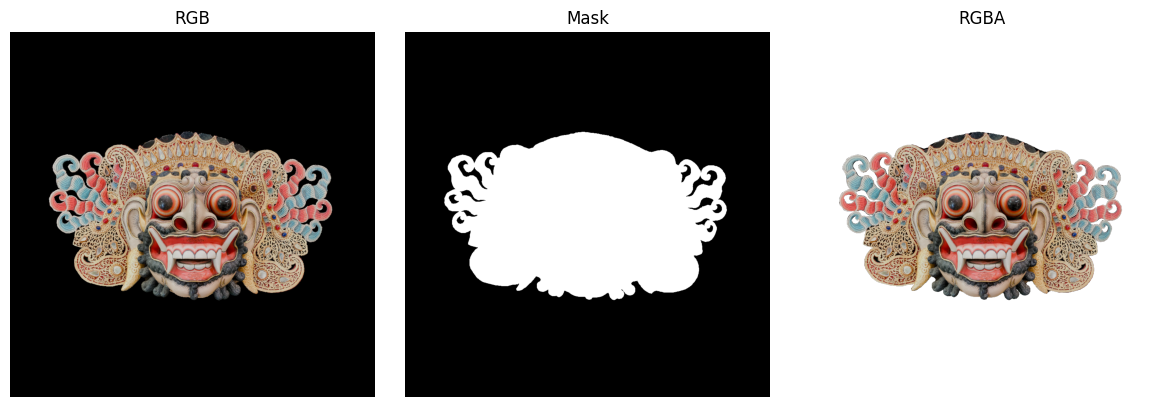

Preview: 1 000.png


In [28]:
# Cell 25: Preview front-view RGBA sample
front_df_preview = ft_test_df[ft_test_df['is_front_view'].astype(str).isin(['True', 'true', '1'])]
if len(front_df_preview) == 0:
    front_df_preview = ft_test_df[ft_test_df['view_name'].astype(str).eq('000.png')]

preview_row = front_df_preview.iloc[0] if len(front_df_preview) else ft_test_df.iloc[0]

rgb = Image.open(preview_row['rgb_path_colab']).convert('RGB')
mask = Image.open(preview_row['mask_path_colab']).convert('L')
rgba = Image.open(preview_row['rgba_input_path']).convert('RGBA')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(rgb); axes[0].set_title('RGB')
axes[1].imshow(mask, cmap='gray'); axes[1].set_title('Mask')
axes[2].imshow(rgba); axes[2].set_title('RGBA')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

print("Preview:", preview_row['mask_id'], preview_row['view_name'])


In [29]:
# Cell 26: Write fine-tuned inference runner
ft_runner_py = REPO_ROOT / 'run_finetuned_colab.py'

ft_runner_code = r'''import os
import argparse
import random
import numpy as np
import torch
from PIL import Image
from torchvision.transforms import v2
from omegaconf import OmegaConf
from einops import rearrange
from tqdm import tqdm
from huggingface_hub import hf_hub_download
from diffusers import DiffusionPipeline, EulerAncestralDiscreteScheduler

from src.utils.train_util import instantiate_from_config
from src.utils.camera_util import (
    FOV_to_intrinsics,
    get_zero123plus_input_cameras,
    get_circular_camera_poses,
)

# lightweight obj saver
import trimesh

def _to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def save_obj(pointnp_px3, facenp_fx3, colornp_px3, fpath):
    pointnp_px3 = _to_numpy(pointnp_px3).astype(np.float32)
    facenp_fx3 = _to_numpy(facenp_fx3).astype(np.int64)
    colornp_px3 = _to_numpy(colornp_px3)
    pointnp_px3 = pointnp_px3 @ np.array([[1, 0, 0], [0, 1, 0], [0, 0, -1]], dtype=np.float32)
    facenp_fx3 = facenp_fx3[:, [2, 1, 0]]
    mesh = trimesh.Trimesh(vertices=pointnp_px3, faces=facenp_fx3, vertex_colors=colornp_px3, process=False)
    mesh.export(fpath, "obj")


def save_obj_with_mtl(pointnp_px3, tcoords_px2, facenp_fx3, facetex_fx3, texmap_hxwx3, fname):
    pointnp_px3 = _to_numpy(pointnp_px3).astype(np.float32)
    tcoords_px2 = _to_numpy(tcoords_px2).astype(np.float32)
    facenp_fx3 = _to_numpy(facenp_fx3).astype(np.int64)
    facetex_fx3 = _to_numpy(facetex_fx3).astype(np.int64)
    texmap_hxwx3 = _to_numpy(texmap_hxwx3).astype(np.float32)

    if pointnp_px3.ndim == 3:
        pointnp_px3 = pointnp_px3[0]
    if tcoords_px2.ndim == 3:
        tcoords_px2 = tcoords_px2[0]
    if facenp_fx3.ndim == 3:
        facenp_fx3 = facenp_fx3[0]
    if facetex_fx3.ndim == 3:
        facetex_fx3 = facetex_fx3[0]

    pointnp_px3 = pointnp_px3 @ np.array([[1, 0, 0], [0, 1, 0], [0, 0, -1]], dtype=np.float32)
    facenp_fx3 = facenp_fx3[:, [2, 1, 0]]
    facetex_fx3 = facetex_fx3[:, [2, 1, 0]]

    fol, na = os.path.split(fname)
    na, _ = os.path.splitext(na)
    os.makedirs(fol, exist_ok=True)
    mtl_path = os.path.join(fol, f"{na}.mtl")
    obj_path = os.path.join(fol, f"{na}.obj")
    tex_path = os.path.join(fol, f"{na}.png")

    with open(mtl_path, "w", encoding="utf-8") as fid:
        fid.write("newmtl material_0\n")
        fid.write("Kd 1 1 1\n")
        fid.write("Ka 0 0 0\n")
        fid.write("Ks 0.4 0.4 0.4\n")
        fid.write("Ns 10\n")
        fid.write("illum 2\n")
        fid.write(f"map_Kd {na}.png\n")

    with open(obj_path, "w", encoding="utf-8") as fid:
        fid.write(f"mtllib {na}.mtl\n")
        for p in pointnp_px3:
            fid.write("v %f %f %f\n" % (p[0], p[1], p[2]))
        for p in tcoords_px2:
            fid.write("vt %f %f\n" % (p[0], p[1]))
        fid.write("usemtl material_0\n")
        for i, f in enumerate(facenp_fx3):
            f1 = f + 1
            f2 = facetex_fx3[i] + 1
            fid.write("f %d/%d %d/%d %d/%d\n" % (f1[0], f2[0], f1[1], f2[1], f1[2], f2[2]))

    tex = np.clip(texmap_hxwx3 * 255.0, 0, 255).astype(np.uint8)
    Image.fromarray(tex).save(tex_path)

def save_video(frames, out_path, fps=30):
    import imageio
    if isinstance(frames, torch.Tensor):
        frames = frames.detach().cpu()
    with imageio.get_writer(str(out_path), fps=fps) as writer:
        for frame in frames:
            if isinstance(frame, torch.Tensor):
                frame = frame.detach().cpu()
            arr = np.asarray(frame)
            if arr.ndim == 3 and arr.shape[0] in [3, 4]:
                arr = np.transpose(arr, (1, 2, 0))
            if arr.dtype != np.uint8:
                if arr.max() <= 1.0:
                    arr = arr * 255.0
                arr = np.clip(arr, 0, 255).astype(np.uint8)
            writer.append_data(arr)

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def get_render_cameras(batch_size=1, M=120, radius=4.0, elevation=20.0, is_flexicubes=False):
    c2ws = get_circular_camera_poses(M=M, radius=radius, elevation=elevation)
    if is_flexicubes:
        cameras = torch.linalg.inv(c2ws)
        cameras = cameras.unsqueeze(0).repeat(batch_size, 1, 1, 1)
    else:
        extrinsics = c2ws.flatten(-2)
        intrinsics = FOV_to_intrinsics(30.0).unsqueeze(0).repeat(M, 1, 1).float().flatten(-2)
        cameras = torch.cat([extrinsics, intrinsics], dim=-1)
        cameras = cameras.unsqueeze(0).repeat(batch_size, 1, 1)
    return cameras

def render_frames(model, planes, render_cameras, render_size=384, chunk_size=1, is_flexicubes=True):
    frames = []
    for i in tqdm(range(0, render_cameras.shape[1], chunk_size), desc="Render video frames"):
        if is_flexicubes:
            frame = model.forward_geometry(
                planes,
                render_cameras[:, i:i + chunk_size],
                render_size=render_size,
            )["img"]
        else:
            frame = model.forward_synthesizer(
                planes,
                render_cameras[:, i:i + chunk_size],
                render_size=render_size,
            )["images_rgb"]
        frames.append(frame)
    return torch.cat(frames, dim=1)[0]

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("config", type=str)
    parser.add_argument("input_path", type=str)
    parser.add_argument("--output_path", type=str, required=True)
    parser.add_argument("--checkpoint", type=str, default="")
    parser.add_argument("--diffusion_steps", type=int, default=75)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--scale", type=float, default=1.0)
    parser.add_argument("--distance", type=float, default=4.5)
    parser.add_argument("--view", type=int, default=6, choices=[4, 6])
    parser.add_argument("--image_size", type=int, default=320)
    parser.add_argument("--no_rembg", action="store_true")
    parser.add_argument("--save_video", action="store_true")
    parser.add_argument("--export_texmap", action="store_true")
    parser.add_argument("--fp16_pipeline", action="store_true")
    args = parser.parse_args()

    seed_everything(args.seed)

    config = OmegaConf.load(args.config)
    config_name = os.path.basename(args.config).replace(".yaml", "")
    model_config = config.model_config
    infer_config = OmegaConf.to_container(config.infer_config, resolve=True)
    is_flexicubes = config_name.startswith("instant-mesh")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_fp16_pipeline = bool(args.fp16_pipeline and device.type == "cuda")

    pipeline = DiffusionPipeline.from_pretrained(
        "sudo-ai/zero123plus-v1.2",
        custom_pipeline="zero123plus",
        torch_dtype=torch.float16 if use_fp16_pipeline else torch.float32,
    )
    pipeline.scheduler = EulerAncestralDiscreteScheduler.from_config(
        pipeline.scheduler.config,
        timestep_spacing="trailing",
    )

    if os.path.exists(config.infer_config.unet_path):
        unet_ckpt_path = config.infer_config.unet_path
    else:
        unet_ckpt_path = hf_hub_download(
            repo_id="TencentARC/InstantMesh",
            filename="diffusion_pytorch_model.bin",
            repo_type="model",
        )
    state_dict = torch.load(unet_ckpt_path, map_location="cpu")
    pipeline.unet.load_state_dict(state_dict, strict=True)
    pipeline = pipeline.to(device)

    model = instantiate_from_config(model_config)

    if args.checkpoint and os.path.exists(args.checkpoint):
        payload = torch.load(args.checkpoint, map_location="cpu")
        if isinstance(payload, dict) and "model_state_dict" in payload:
            model.load_state_dict(payload["model_state_dict"], strict=False)
            print("Loaded fine-tuned checkpoint:", args.checkpoint)
        else:
            model.load_state_dict(payload, strict=False)
            print("Loaded checkpoint state dict:", args.checkpoint)
    else:
        if os.path.exists(config.infer_config.model_path):
            model_ckpt_path = config.infer_config.model_path
        else:
            model_ckpt_path = hf_hub_download(
                repo_id="TencentARC/InstantMesh",
                filename=f"{config_name.replace('-', '_')}.ckpt",
                repo_type="model",
            )
        payload = torch.load(model_ckpt_path, map_location="cpu")
        state = payload["state_dict"] if isinstance(payload, dict) and "state_dict" in payload else payload
        state = {k[14:]: v for k, v in state.items() if k.startswith("lrm_generator.")}
        model.load_state_dict(state, strict=True)
        print("Loaded pretrained checkpoint:", model_ckpt_path)

    model = model.to(device)
    if is_flexicubes:
        model.init_flexicubes_geometry(device, fovy=30.0)
    model = model.float().eval()

    image_path = os.path.join(args.output_path, config_name, "images")
    mesh_path = os.path.join(args.output_path, config_name, "meshes")
    video_path = os.path.join(args.output_path, config_name, "videos")
    os.makedirs(image_path, exist_ok=True)
    os.makedirs(mesh_path, exist_ok=True)
    os.makedirs(video_path, exist_ok=True)

    input_files = [args.input_path] if not os.path.isdir(args.input_path) else [
        os.path.join(args.input_path, f)
        for f in sorted(os.listdir(args.input_path))
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp"))
    ]

    outputs = []
    for image_file in input_files:
        name = os.path.basename(image_file).split(".")[0]
        input_image = Image.open(image_file)
        output_image = pipeline(input_image, num_inference_steps=args.diffusion_steps).images[0]
        output_image.save(os.path.join(image_path, f"{name}.png"))

        images = np.asarray(output_image, dtype=np.float32) / 255.0
        images = torch.from_numpy(images).permute(2, 0, 1).contiguous().float()
        images = rearrange(images, "c (n h) (m w) -> (n m) c h w", n=3, m=2)
        outputs.append({"name": name, "images": images})

    del pipeline
    if device.type == "cuda":
        torch.cuda.empty_cache()

    input_cameras = get_zero123plus_input_cameras(batch_size=1, radius=4.0 * args.scale).to(device)

    for sample in outputs:
        name = sample["name"]
        images = sample["images"].unsqueeze(0).to(device).float()
        images = v2.functional.resize(images, args.image_size, interpolation=3, antialias=True).clamp(0, 1)

        local_input_cameras = input_cameras.clone()
        if args.view == 4:
            indices = torch.tensor([0, 2, 4, 5]).long().to(device)
            images = images[:, indices]
            local_input_cameras = local_input_cameras[:, indices]

        with torch.no_grad():
            planes = model.forward_planes(images, local_input_cameras)
            planes = planes.float()
            mesh_out = model.extract_mesh(
                planes,
                use_texture_map=args.export_texmap,
                **infer_config,
            )

        mesh_path_idx = os.path.join(mesh_path, f"{name}.obj")
        if args.export_texmap:
            vertices, faces, uvs, mesh_tex_idx, tex_map = mesh_out
            save_obj_with_mtl(
                vertices,
                uvs,
                faces,
                mesh_tex_idx,
                tex_map.permute(1, 2, 0),
                mesh_path_idx,
            )
        else:
            vertices, faces, vertex_colors = mesh_out
            save_obj(vertices, faces, vertex_colors, mesh_path_idx)

        if args.save_video:
            render_size = infer_config.get("render_resolution", 384)
            render_cameras = get_render_cameras(
                batch_size=1,
                M=120,
                radius=args.distance,
                elevation=20.0,
                is_flexicubes=is_flexicubes,
            ).to(device)
            with torch.no_grad():
                frames = render_frames(
                    model,
                    planes,
                    render_cameras=render_cameras,
                    render_size=render_size,
                    chunk_size=1,
                    is_flexicubes=is_flexicubes,
                )
            save_video(frames, os.path.join(video_path, f"{name}.mp4"), fps=30)

if __name__ == "__main__":
    main()
'''

ft_runner_py.write_text(ft_runner_code, encoding='utf-8')
print("Wrote:", ft_runner_py)


Wrote: /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/run_finetuned_colab.py


In [30]:
# Cell 27: Verify fine-tuned inference runner syntax
import py_compile
py_compile.compile(str(ft_runner_py), doraise=True)
print("Syntax OK:", ft_runner_py)


Syntax OK: /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/run_finetuned_colab.py


In [31]:
# Cell 28 FIX: Fine-tuned inference helper
import subprocess
import sys
from pathlib import Path

def ft_find_outputs(output_path: Path):
    obj_files = sorted(Path(output_path).rglob('*.obj'))
    mp4_files = sorted(Path(output_path).rglob('*.mp4'))
    png_files = sorted(Path(output_path).rglob('*.png'))
    return {
        'mesh_obj': str(obj_files[0]) if obj_files else '',
        'video_mp4': str(mp4_files[0]) if mp4_files else '',
        'mv_image': str(png_files[0]) if png_files else '',
    }

def ft_run_single(rgba_input_path: Path, output_path: Path):
    output_path.mkdir(parents=True, exist_ok=True)

    existing = ft_find_outputs(output_path)
    if (not FT_SKIP_EXISTING) and output_path.exists():
        shutil.rmtree(output_path)
        output_path.mkdir(parents=True, exist_ok=True)
        existing = ft_find_outputs(output_path)

    if FT_SKIP_EXISTING and existing['mesh_obj'] and Path(existing['mesh_obj']).exists():
        return {
            'returncode': 0,
            'log_path': '',
            'stdout_tail': '',
            'stderr_tail': '',
            'ok': True,
            **existing,
            'checkpoint_used': str(SELECTED_FT_CKPT) if SELECTED_FT_CKPT else 'pretrained',
        }

    cmd = [
        sys.executable,
        str(ft_runner_py),
        str(IM_CONFIG),
        str(rgba_input_path),
        '--output_path', str(output_path),
        '--diffusion_steps', str(FT_DIFFUSION_STEPS),
        '--seed', str(SEED),
        '--scale', str(FT_IM_SCALE),
        '--distance', str(FT_IM_DISTANCE),
        '--view', str(FT_IM_VIEW),
        '--image_size', str(FT_IMAGE_SIZE),
    ]

    if SELECTED_FT_CKPT is not None:
        cmd += ['--checkpoint', str(SELECTED_FT_CKPT)]
    if FT_USE_FP16_PIPELINE:
        cmd.append('--fp16_pipeline')
    if FT_NO_REMBG:
        cmd.append('--no_rembg')
    if FT_SAVE_VIDEO:
        cmd.append('--save_video')
    if FT_EXPORT_TEXMAP:
        # Runner lama mungkin belum support flag ini. Kalau error, set FT_EXPORT_TEXMAP=False.
        cmd.append('--export_texmap')

    log_path = FT_LOG_ROOT / f"{output_path.parent.name}_{output_path.name}.log"

    print('[RUN]', ' '.join(cmd))
    proc = subprocess.run(cmd, cwd=str(REPO_ROOT), capture_output=True, text=True)

    log_path.write_text(
        '[STDOUT]\n' + (proc.stdout or '') + '\n\n[STDERR]\n' + (proc.stderr or ''),
        encoding='utf-8',
        errors='ignore'
    )

    outputs = ft_find_outputs(output_path)

    return {
        'returncode': proc.returncode,
        'log_path': str(log_path),
        'stdout_tail': (proc.stdout or '')[-3000:],
        'stderr_tail': (proc.stderr or '')[-3000:],
        'ok': proc.returncode == 0 and bool(outputs['mesh_obj']),
        **outputs,
        'checkpoint_used': str(SELECTED_FT_CKPT) if SELECTED_FT_CKPT else 'pretrained',
    }

In [32]:
# FIX: import module yang dibutuhkan oleh ft_run_single
import subprocess
import sys
import json
import os
import shutil
from pathlib import Path

print("subprocess imported OK")

subprocess imported OK


In [33]:
# FIX: import display video
from IPython.display import Video, display

print("Video import OK")

Video import OK


In [34]:
# Cell 29: Smoke test fine-tuned inference
if FT_RUN_SMOKE_TEST:
    smoke_row = ft_test_df.iloc[0]
    smoke_out_dir = Path(smoke_row['pred_output_dir'])
    smoke_result = ft_run_single(Path(smoke_row['rgba_input_path']), smoke_out_dir)

    smoke_ft_df = pd.DataFrame([{**smoke_row.to_dict(), **smoke_result}])
    smoke_ft_df.to_csv(FT_INFER_ROOT / 'smoke_finetuned_result.csv', index=False)
    display(smoke_ft_df)

    if not smoke_result['ok']:
        print('Smoke FT inference gagal. Cek log:', smoke_result['log_path'])
        print(smoke_result['stderr_tail'])
        raise RuntimeError('Smoke FT inference gagal.')
    else:
        print("Smoke FT inference sukses.")
        if smoke_result.get('video_mp4') and Path(smoke_result['video_mp4']).exists():
            display(Video(smoke_result['video_mp4'], embed=True))
else:
    print("FT_RUN_SMOKE_TEST=False")


FT_RUN_SMOKE_TEST=False


In [35]:
# Cell 30: Full fine-tuned batch inference
ft_pred_records = []

if FT_RUN_FULL_BATCH:
    for _, row in tqdm(ft_test_df.iterrows(), total=len(ft_test_df), desc='Fine-tuned test inference'):
        out_dir = Path(row['pred_output_dir'])
        try:
            result = ft_run_single(Path(row['rgba_input_path']), out_dir)
        except Exception as e:
            result = {
                'returncode': -1,
                'log_path': '',
                'stdout_tail': '',
                'stderr_tail': str(e),
                'ok': False,
                'mesh_obj': '',
                'video_mp4': '',
                'mv_image': '',
                'checkpoint_used': str(SELECTED_FT_CKPT) if SELECTED_FT_CKPT else 'pretrained',
            }
        ft_pred_records.append({**row.to_dict(), **result})

    ft_pred_df = pd.DataFrame(ft_pred_records)
else:
    ft_pred_df = pd.DataFrame()
    print("FT_RUN_FULL_BATCH=False")

ft_pred_csv = FT_INFER_ROOT / 'finetuned_test_predictions.csv'
ft_pred_df.to_csv(ft_pred_csv, index=False)

print("Saved:", ft_pred_csv)
display(ft_pred_df.head() if len(ft_pred_df) else ft_pred_df)


Fine-tuned test inference:   0%|          | 0/108 [00:00<?, ?it/s]

[RUN] /usr/bin/python3 /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/run_finetuned_colab.py /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/configs/instant-mesh-large.yaml /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I4_topology_aware_max_v1/finetuned_inference/rgba_inputs/1/000.png --output_path /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I4_topology_aware_max_v1/finetuned_inference/pred_meshes/1/000 --diffusion_steps 100 --seed 42 --scale 1.0 --distance 4.5 --view 6 --image_size 384 --checkpoint /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I4_topology_aware_max_v1/checkpoints/best_meshval_tmd_I4_topology_aware_max.pt --fp16_pipeline --no_rembg --save_video --export_texmap
[RUN] /usr/bin/python3 /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/run_finetuned_colab.py /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/configs/instant-mesh-large.yaml /content/

,mask_id,view_id,view_name,radius_used,rgb_path,mask_path,depth_path,depth_exr_path,normal_path,depth_stats_path,...,gt_mesh_path_colab,returncode,log_path,stdout_tail,stderr_tail,ok,mesh_obj,video_mp4,mv_image,checkpoint_used
0,1,0,000.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,0,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,Loaded fine-tuned checkpoint: /content/drive/M...,"▌ | 79/120 [00:12<00:06, 6.48it/s]\nRender ...",True,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...
1,1,1,001.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,0,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,Loaded fine-tuned checkpoint: /content/drive/M...,"▌ | 79/120 [00:12<00:06, 6.47it/s]\nRender ...",True,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...
2,1,2,002.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,0,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,Loaded fine-tuned checkpoint: /content/drive/M...,"▌ | 79/120 [00:12<00:06, 6.46it/s]\nRender ...",True,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...
3,1,3,003.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,0,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,Loaded fine-tuned checkpoint: /content/drive/M...,"▌ | 79/120 [00:12<00:06, 6.45it/s]\nRender ...",True,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...
4,1,4,004.png,3.0,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,0,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,Loaded fine-tuned checkpoint: /content/drive/M...,"▌ | 79/120 [00:12<00:06, 6.46it/s]\nRender ...",True,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...


In [36]:
# Cell 31: Metric helpers CD / UHD / TMD
import inspect
from ripser import ripser
from persim import wasserstein
import trimesh
from scipy.spatial import cKDTree

def load_mesh_safe(mesh_path: Path):
    mesh = trimesh.load(mesh_path, force='mesh', process=False)
    if isinstance(mesh, trimesh.Scene):
        mesh = trimesh.util.concatenate(tuple(g for g in mesh.geometry.values()))
    return mesh

def sample_points_from_mesh(mesh_path: Path, n=20000):
    mesh = load_mesh_safe(mesh_path)
    pts, _ = trimesh.sample.sample_surface(mesh, n)
    return np.asarray(pts, dtype=np.float32)

def nearest_dist(a, b):
    tree = cKDTree(b)
    d, _ = tree.query(a, k=1)
    return d

def chamfer_distance(a, b):
    d_ab = nearest_dist(a, b)
    d_ba = nearest_dist(b, a)
    return float(d_ab.mean() + d_ba.mean())

def uniform_hausdorff_distance(a, b):
    d_ab = nearest_dist(a, b)
    d_ba = nearest_dist(b, a)
    return float(max(d_ab.max(), d_ba.max()))

def wasserstein_safe(dgm1, dgm2, p=1):
    sig = inspect.signature(wasserstein)
    kwargs = {}
    if 'matching' in sig.parameters:
        kwargs['matching'] = False
    if 'p' in sig.parameters:
        kwargs['p'] = p
    elif 'order' in sig.parameters:
        kwargs['order'] = p
    return wasserstein(dgm1, dgm2, **kwargs)

def filter_finite_dgm(dgm):
    dgm = np.asarray(dgm)
    if dgm.size == 0:
        return dgm
    mask = np.isfinite(dgm[:, 0]) & np.isfinite(dgm[:, 1])
    return dgm[mask]

def tmd_distance(points_pred, points_gt, maxdim=1, thresh=1.5, p=1):
    dg_pred = ripser(points_pred, maxdim=maxdim, thresh=thresh)['dgms']
    dg_gt = ripser(points_gt, maxdim=maxdim, thresh=thresh)['dgms']
    dist = 0.0
    for dim in range(maxdim + 1):
        d1 = filter_finite_dgm(dg_pred[dim])
        d2 = filter_finite_dgm(dg_gt[dim])
        dist += float(wasserstein_safe(d1, d2, p=p))
    return float(dist)


In [37]:
# Cell 32 FIX: Run evaluation CD / UHD / TMD
# Robust terhadap metadata final: gt_mesh_path / gt_mesh_path_colab / mesh_src_path_colab.

from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

LOCAL_PREFIX = "/home/birhasani/Tugas_Akhir"
COLAB_PREFIX = "/content/drive/MyDrive/Tugas_Akhir"

def to_colab_path_str(p):
    p = str(p)
    if p.startswith(LOCAL_PREFIX):
        p = p.replace(LOCAL_PREFIX, COLAB_PREFIX)
    return p

def get_first_value(row, candidates, default=""):
    for c in candidates:
        if c in row.index:
            v = row[c]
            if pd.notna(v) and str(v) not in ["", "nan", "None"]:
                return str(v)
    return default

ft_metrics_rows = []

if FT_RUN_EVALUATION:
    if "ft_pred_df" not in globals() or len(ft_pred_df) == 0:
        ft_pred_csv = FT_INFER_ROOT / "finetuned_test_predictions.csv"
        print("Loading:", ft_pred_csv)
        ft_pred_df = pd.read_csv(ft_pred_csv)

    if "ok" in ft_pred_df.columns:
        ok_df = ft_pred_df[ft_pred_df["ok"] == True].copy()
    elif "mesh_ok" in ft_pred_df.columns:
        ok_df = ft_pred_df[ft_pred_df["mesh_ok"] == True].copy()
    else:
        ok_df = ft_pred_df.copy()

    print("Rows for evaluation:", len(ok_df))
    print("Available columns:", ok_df.columns.tolist())

    for _, row in tqdm(ok_df.iterrows(), total=len(ok_df), desc="Evaluate fine-tuned CD/UHD/TMD"):
        pred_mesh_str = get_first_value(row, [
            "mesh_obj",
            "pred_mesh_path",
            "pred_mesh_obj",
            "mesh_path",
        ])

        gt_mesh_str = get_first_value(row, [
            "mesh_src_path_colab",
            "gt_mesh_path_colab",
            "gt_mesh_path",
            "mesh_src_path",
        ])

        rgb_path_str = get_first_value(row, ["rgb_path_colab", "rgb_path"])
        mask_path_str = get_first_value(row, ["mask_path_colab", "mask_path"])
        rgba_input_str = get_first_value(row, ["rgba_input_path", "input_rgba_path", "input_path"])

        pred_mesh = Path(to_colab_path_str(pred_mesh_str))
        gt_mesh = Path(to_colab_path_str(gt_mesh_str))

        rec = {
            "split": row.get("split", ""),
            "mask_id": row.get("mask_id", ""),
            "view_index": row.get("view_index", ""),
            "view_name": row.get("view_name", ""),
            "is_front_view": row.get("is_front_view", ""),
            "rgb_path": to_colab_path_str(rgb_path_str),
            "mask_path": to_colab_path_str(mask_path_str),
            "rgba_input_path": to_colab_path_str(rgba_input_str),
            "pred_mesh_path": str(pred_mesh),
            "gt_mesh_path": str(gt_mesh),
            "pred_exists": pred_mesh.exists(),
            "gt_exists": gt_mesh.exists(),
            "video_mp4": row.get("video_mp4", row.get("mv_video_mp4", "")),
            "checkpoint_used": row.get("checkpoint_used", str(SELECTED_FT_CKPT) if "SELECTED_FT_CKPT" in globals() else ""),
            "ok": False,
            "cd": np.nan,
            "uhd": np.nan,
            "tmd": np.nan,
            "error": "",
        }

        try:
            if not pred_mesh.exists():
                raise FileNotFoundError(f"Pred mesh not found: {pred_mesh}")
            if not gt_mesh.exists():
                raise FileNotFoundError(f"GT mesh not found: {gt_mesh}")

            pred_pts = sample_points_from_mesh(pred_mesh, N_CD)
            gt_pts = sample_points_from_mesh(gt_mesh, N_CD)

            rec["cd"] = chamfer_distance(pred_pts, gt_pts)
            rec["uhd"] = uniform_hausdorff_distance(pred_pts, gt_pts)

            pred_tmd = sample_points_from_mesh(pred_mesh, N_TMD)
            gt_tmd = sample_points_from_mesh(gt_mesh, N_TMD)
            rec["tmd"] = tmd_distance(pred_tmd, gt_tmd, maxdim=TMD_MAXDIM, thresh=TMD_THRESH)
            rec["ok"] = True

        except Exception as e:
            rec["error"] = str(e)

        ft_metrics_rows.append(rec)

    ft_metrics_df = pd.DataFrame(ft_metrics_rows)

else:
    ft_metrics_df = pd.DataFrame()
    print("FT_RUN_EVALUATION=False")

ft_metrics_csv = FT_EVAL_ROOT / "metrics_finetuned_test.csv"
ft_metrics_xlsx = FT_EVAL_ROOT / "metrics_finetuned_test.xlsx"

ft_metrics_df.to_csv(ft_metrics_csv, index=False)

with pd.ExcelWriter(ft_metrics_xlsx) as writer:
    ft_metrics_df.to_excel(writer, index=False, sheet_name="per_sample")
    if len(ft_metrics_df):
        valid = ft_metrics_df[ft_metrics_df["ok"] == True].copy()
        if len(valid):
            valid.groupby("mask_id")[["cd", "uhd", "tmd"]].mean().reset_index().to_excel(writer, index=False, sheet_name="per_mask")
            valid.groupby("view_name")[["cd", "uhd", "tmd"]].mean().reset_index().to_excel(writer, index=False, sheet_name="per_view")
            front_valid = valid[
                valid["view_name"].astype(str).eq("000.png") |
                valid["is_front_view"].astype(str).isin(["True", "true", "1"])
            ]
            front_valid.to_excel(writer, index=False, sheet_name="front_view")

print("Saved:", ft_metrics_csv)
print("Saved:", ft_metrics_xlsx)

if len(ft_metrics_df):
    print("OK count:")
    print(ft_metrics_df["ok"].value_counts(dropna=False))
    print("\nMissing/error samples:")
    display(ft_metrics_df[ft_metrics_df["ok"] != True][[
        "mask_id", "view_name", "pred_exists", "gt_exists", "pred_mesh_path", "gt_mesh_path", "error"
    ]].head(20))

display(ft_metrics_df.head() if len(ft_metrics_df) else ft_metrics_df)


Rows for evaluation: 108
Available columns: ['mask_id', 'view_id', 'view_name', 'radius_used', 'rgb_path', 'mask_path', 'depth_path', 'depth_exr_path', 'normal_path', 'depth_stats_path', 'camera_json', 'camera_dn_json', 'gt_mesh_path', 'ok_rgb', 'ok_mask', 'ok_depth', 'ok_depth_exr', 'ok_normal', 'ok_stats', 'ok_camera', 'ok_mesh', 'ok_all', 'split', 'view_index', 'mesh_src_path', 'camera_json_path', 'depth_vis_path', 'normal_png_path', 'rgba_input_path', 'pred_output_dir', 'pred_mesh_path', 'is_front_view', 'rgba_exists', 'rgb_path_colab', 'mask_path_colab', 'depth_path_colab', 'normal_path_colab', 'gt_mesh_path_colab', 'returncode', 'log_path', 'stdout_tail', 'stderr_tail', 'ok', 'mesh_obj', 'video_mp4', 'mv_image', 'checkpoint_used']


Evaluate fine-tuned CD/UHD/TMD:   0%|          | 0/108 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I4_topology_aware_max_v1/finetuned_inference/evaluation/metrics_finetuned_test.csv
Saved: /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I4_topology_aware_max_v1/finetuned_inference/evaluation/metrics_finetuned_test.xlsx
OK count:
ok
True    108
Name: count, dtype: int64

Missing/error samples:


,mask_id,view_name,pred_exists,gt_exists,pred_mesh_path,gt_mesh_path,error


,split,mask_id,view_index,view_name,is_front_view,rgb_path,mask_path,rgba_input_path,pred_mesh_path,gt_mesh_path,pred_exists,gt_exists,video_mp4,checkpoint_used,ok,cd,uhd,tmd,error
0,test,1,0,000.png,True,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,True,0.342535,0.569321,17.159120,
1,test,1,1,001.png,False,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,True,0.357251,0.650482,19.976664,
2,test,1,2,002.png,False,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,True,0.403532,0.869403,20.421037,
3,test,1,3,003.png,False,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,True,0.405679,0.846543,18.573574,
4,test,1,4,004.png,False,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,True,0.394499,0.835684,17.291737,


In [ ]:
# Cell 33: Summary tables + pretrained reference comparison
if len(ft_metrics_df):
    valid_df = ft_metrics_df[ft_metrics_df['ok'] == True].copy()
    overall = valid_df[['cd', 'uhd', 'tmd']].mean().to_frame('finetuned_mean')
    ref = pd.DataFrame({'pretrained_ref': PRETRAINED_REF})
    comp = overall.join(ref)
    comp['delta_abs'] = comp['finetuned_mean'] - comp['pretrained_ref']
    comp['delta_pct'] = comp['delta_abs'] / comp['pretrained_ref'] * 100
    display(comp)

    by_mask = valid_df.groupby('mask_id')[['cd', 'uhd', 'tmd']].mean().reset_index()
    display(by_mask)

    best3_df = valid_df.sort_values('cd').head(3).copy()
    worst3_df = valid_df.sort_values('cd', ascending=False).head(3).copy()
    front_best3_df = valid_df[valid_df['view_name'].astype(str).eq('000.png')].sort_values('cd').head(3).copy()
    front_worst3_df = valid_df[valid_df['view_name'].astype(str).eq('000.png')].sort_values('cd', ascending=False).head(3).copy()
else:
    print('No metrics available yet.')


In [45]:
# Cell 33: Summary tables + pretrained reference comparison
if len(ft_metrics_df):
    valid_df = ft_metrics_df[ft_metrics_df['ok'] == True].copy()
    overall = valid_df[['cd', 'uhd', 'tmd']].mean().to_frame('finetuned_mean')
    ref = pd.DataFrame({'pretrained_ref': PRETRAINED_REF})
    comp = overall.join(ref)
    comp['delta_abs'] = comp['finetuned_mean'] - comp['pretrained_ref']
    comp['delta_pct'] = comp['delta_abs'] / comp['pretrained_ref'] * 100
    display(comp)

    by_mask = valid_df.groupby('mask_id')[['cd', 'uhd', 'tmd']].mean().reset_index()
    display(by_mask)

    best3_df = valid_df.sort_values('cd').head(3).copy()
    worst3_df = valid_df.sort_values('cd', ascending=False).head(3).copy()
    front_best3_df = valid_df[valid_df['view_name'].astype(str).eq('000.png')].sort_values('cd').head(3).copy()
    front_worst3_df = valid_df[valid_df['view_name'].astype(str).eq('000.png')].sort_values('cd', ascending=False).head(3).copy()
else:
    print('No metrics available yet.')


,finetuned_mean,pretrained_ref,delta_abs,delta_pct
cd,0.425372,0.541045,-0.115673,-21.379593
uhd,0.771353,0.802961,-0.031608,-3.936455
tmd,27.653324,6.298061,21.355263,339.076783


,mask_id,cd,uhd,tmd
0,1,0.393983,0.752797,21.965992
1,21,0.403250,0.797798,27.531171
2,4,0.478882,0.763463,33.462807


In [ ]:
# Cell 34: Interactive 3D helper
def show_mesh_plotly(mesh_path: Path, title='Mesh', max_faces=250000):
    mesh = load_mesh_safe(mesh_path)
    v = np.asarray(mesh.vertices)
    f = np.asarray(mesh.faces)

    if len(f) > max_faces:
        idx = np.random.choice(len(f), size=max_faces, replace=False)
        f = f[idx]

    fig = go.Figure(
        data=[
            go.Mesh3d(
                x=v[:, 0],
                y=v[:, 1],
                z=v[:, 2],
                i=f[:, 0],
                j=f[:, 1],
                k=f[:, 2],
                opacity=1.0,
            )
        ]
    )
    fig.update_layout(
        title=title,
        scene_aspectmode='data',
        width=700,
        height=650,
        margin=dict(l=0, r=0, t=40, b=0),
    )
    fig.show()

def show_sample_card(row, title_prefix='Sample'):
    print(f"{title_prefix} | mask={row['mask_id']} | view={row['view_name']} | CD={row['cd']:.6f} | UHD={row['uhd']:.6f} | TMD={row['tmd']:.6f}")

    rgb = Image.open(row['rgb_path']).convert('RGB')
    rgba = Image.open(row['rgba_input_path']).convert('RGBA')

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(rgb); axes[0].set_title('RGB input')
    axes[1].imshow(rgba); axes[1].set_title('RGBA input')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    if row.get('video_mp4', '') and Path(row['video_mp4']).exists():
        display(Video(row['video_mp4'], embed=True))

    show_mesh_plotly(Path(row['pred_mesh_path']), title=f"{title_prefix} Pred | mask {row['mask_id']} | {row['view_name']}")
    show_mesh_plotly(Path(row['gt_mesh_path']), title=f"{title_prefix} GT | mask {row['mask_id']}")


In [46]:
# Cell 34: Interactive 3D helper
def show_mesh_plotly(mesh_path: Path, title='Mesh', max_faces=250000):
    mesh = load_mesh_safe(mesh_path)
    v = np.asarray(mesh.vertices)
    f = np.asarray(mesh.faces)

    if len(f) > max_faces:
        idx = np.random.choice(len(f), size=max_faces, replace=False)
        f = f[idx]

    fig = go.Figure(
        data=[
            go.Mesh3d(
                x=v[:, 0],
                y=v[:, 1],
                z=v[:, 2],
                i=f[:, 0],
                j=f[:, 1],
                k=f[:, 2],
                opacity=1.0,
            )
        ]
    )
    fig.update_layout(
        title=title,
        scene_aspectmode='data',
        width=700,
        height=650,
        margin=dict(l=0, r=0, t=40, b=0),
    )
    fig.show()

def show_sample_card(row, title_prefix='Sample'):
    print(f"{title_prefix} | mask={row['mask_id']} | view={row['view_name']} | CD={row['cd']:.6f} | UHD={row['uhd']:.6f} | TMD={row['tmd']:.6f}")

    rgb = Image.open(row['rgb_path']).convert('RGB')
    rgba = Image.open(row['rgba_input_path']).convert('RGBA')

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(rgb); axes[0].set_title('RGB input')
    axes[1].imshow(rgba); axes[1].set_title('RGBA input')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    if row.get('video_mp4', '') and Path(row['video_mp4']).exists():
        display(Video(row['video_mp4'], embed=True))

    show_mesh_plotly(Path(row['pred_mesh_path']), title=f"{title_prefix} Pred | mask {row['mask_id']} | {row['view_name']}")
    show_mesh_plotly(Path(row['gt_mesh_path']), title=f"{title_prefix} GT | mask {row['mask_id']}")


In [44]:
# Cell 35: Showcase 3 best

# Plotly imports for mesh visualization

import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("Plotly loaded.")

if len(ft_metrics_df):
    print("=== 3 BEST FINE-TUNED TEST SAMPLES ===")
    for i, row in best3_df.reset_index(drop=True).iterrows():
        show_sample_card(row, title_prefix=f"BEST #{i+1}")
else:
    print("Metrics belum tersedia.")


Output hidden; open in https://colab.research.google.com to view.

In [41]:
# Cell 36: Showcase 3 worst
if len(ft_metrics_df):
    print("=== 3 WORST FINE-TUNED TEST SAMPLES ===")
    for i, row in worst3_df.reset_index(drop=True).iterrows():
        show_sample_card(row, title_prefix=f"WORST #{i+1}")
else:
    print("Metrics belum tersedia.")


Output hidden; open in https://colab.research.google.com to view.

In [42]:
# Cell 37: Showcase front view best/worst
if len(ft_metrics_df):
    print("=== FRONT VIEW BEST 3 ===")
    for i, row in front_best3_df.reset_index(drop=True).iterrows():
        show_sample_card(row, title_prefix=f"FRONT BEST #{i+1}")

    print("=== FRONT VIEW WORST 3 ===")
    for i, row in front_worst3_df.reset_index(drop=True).iterrows():
        show_sample_card(row, title_prefix=f"FRONT WORST #{i+1}")
else:
    print("Metrics belum tersedia.")


Output hidden; open in https://colab.research.google.com to view.

In [43]:
# Cell 38: Save complete fine-tuning + evaluation summary
complete_summary = {
    'out_root': str(OUT_ROOT),
    'selected_checkpoint': str(SELECTED_FT_CKPT) if SELECTED_FT_CKPT else 'pretrained',
    'ft_infer_root': str(FT_INFER_ROOT),
    'i4_target_min_trainable': I2_TARGET_MIN_TRAINABLE,
    'i4_target_max_trainable': I2_TARGET_MAX_TRAINABLE,
    'pretrained_ref': PRETRAINED_REF,
    'metrics_csv': str(FT_EVAL_ROOT / 'metrics_finetuned_test.csv'),
    'showcase_root': str(FT_SHOWCASE_ROOT),
    'front_view_definition': 'view_name == 000.png or is_front_view == True',
    'metrics': ['CD', 'UHD', 'TMD'],
}

complete_summary_path = OUT_ROOT / 'complete_finetune_eval_summary.json'
complete_summary_path.write_text(json.dumps(complete_summary, indent=2), encoding='utf-8')

print("Saved:", complete_summary_path)
print(json.dumps(complete_summary, indent=2))


Saved: /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I4_topology_aware_max_v1/complete_finetune_eval_summary.json
{
  "out_root": "/content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I4_topology_aware_max_v1",
  "selected_checkpoint": "/content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I4_topology_aware_max_v1/checkpoints/best_meshval_tmd_I4_topology_aware_max.pt",
  "ft_infer_root": "/content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I4_topology_aware_max_v1/finetuned_inference",
  "i4_target_min_trainable": 8000000,
  "i4_target_max_trainable": 20000000,
  "pretrained_ref": {
    "cd": 0.541045,
    "uhd": 0.802961,
    "tmd": 6.298061
  },
  "metrics_csv": "/content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I4_topology_aware_max_v1/finetuned_inference/evaluation/metrics_finetuned_test.csv",
  "showcase_root": "/content/drive/M